# Step 1. Define Paths and Import Libraries

In [8]:
from pathlib import Path
import mne
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
import pywt
from scipy.stats import randint, uniform
# Machine learning

from sklearn.model_selection import cross_val_score, StratifiedKFold,train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import lightgbm as lgb
# Visualization
import matplotlib.pyplot as plt

# Path to the folder with your .fif blocks
data_folder = Path('../bids_dataset/derivatives/annotated')
block_files = sorted(list(data_folder.glob('blk*_annot_raw.fif')))
print(f'Found {len(block_files)} .fif blocks')
block_files[:3]  # Show a few for sanity check


Found 20 .fif blocks


[PosixPath('../bids_dataset/derivatives/annotated/blk00_annot_raw.fif'),
 PosixPath('../bids_dataset/derivatives/annotated/blk01_annot_raw.fif'),
 PosixPath('../bids_dataset/derivatives/annotated/blk02_annot_raw.fif')]

# Step 2. Helper: Frequency Bands and Hjorth Functions

In [9]:
# Frequency bands
FREQ_BANDS = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 50),
}

# Hjorth parameters
def compute_hjorth(epoch):
    """Compute Hjorth parameters for a single epoch (n_channels, n_times)"""
    def hjorth_params(x):
        dx = np.diff(x)
        ddx = np.diff(dx)
        var_zero = np.var(x)
        var_d1 = np.var(dx)
        var_d2 = np.var(ddx)
        mobility = np.sqrt(var_d1 / var_zero) if var_zero > 0 else 0
        complexity = np.sqrt(var_d2 / var_d1) / mobility if var_d1 > 0 and mobility > 0 else 0
        return var_zero, mobility, complexity

    return np.array([hjorth_params(ch) for ch in epoch])

def wavelet_energy_features(epoch, wavelet='db4', level=3):
    """
    Extracts the energy of each node from the wavelet packet decomposition of an EEG segment (single channel).
    Args:
        epoch: 1D numpy array (samples,)
        wavelet: Wavelet type (default 'db4')
        level: Decomposition level (default 3)
    Returns:
        energies: numpy array with the energy per node
    """
    wp = pywt.WaveletPacket(data=epoch, wavelet=wavelet, mode='symmetric', maxlevel=level)
    nodes = wp.get_level(level, order='freq')
    energies = np.array([np.sum(np.square(n.data)) for n in nodes])
    return energies

# Step 3. Epoch Extraction and Feature Computation

In [10]:
# Parameters for window-based features
EPOCH_LEN = 2.0  # seconds
EPOCH_STEP = 0.5 # seconds

block_files = sorted(Path("../bids_dataset/derivatives/annotated").glob("blk*_annot_raw.fif"))
eeg_channels = ["Fp1", "Fp2", "C3", "C4", "T7", "T8", "O1", "O2", "F3", "F4", "Fz", "Pz", "P3", "P4"]


all_features_epoch = []
all_features_epoch_psd = []
all_features_logband = []
all_features_relative = []
all_features_hjorth = []
all_features_wavelet = []

all_labels = []            # label per window

# 1. Find max phrase segment length (in samples)
sfreq = 125
max_samples = 0

for fif_file in tqdm(block_files, desc="Calculating max phrase length"):
    raw = mne.io.read_raw_fif(fif_file, preload=False, verbose=False)
    annots = raw.annotations
    for onset, duration, desc in zip(annots.onset, annots.duration, annots.description):
        if desc.startswith('phrase/'):
            samples = int(duration * sfreq)
            if samples > max_samples:
                max_samples = samples

print(f"Max phrase segment: {max_samples} samples ({max_samples/sfreq:.2f} s)")

# 2. Extract features (including "raw" one per phrase)
for fif_file in tqdm(block_files, desc="Extracting features"):
    raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)
    sfreq = raw.info['sfreq']
    events, event_ids = mne.events_from_annotations(raw)
    annots = raw.annotations

    # -------- Sliding window features --------
    phrase_events = {k: v for k, v in event_ids.items() if k.startswith('phrase/')}
    epochs = mne.Epochs(
        raw,
        events,
        event_id=phrase_events,
        tmin=0, tmax=EPOCH_LEN,
        baseline=None,
        preload=True,
        detrend=1,
        picks='eeg'
    )
    epoch_data = epochs.get_data()  # (n_events, n_channels, n_times)
    for i, ep in enumerate(epoch_data):
        label = epochs.events[i, 2]
        n_samples = ep.shape[1]
        win_len = int(EPOCH_LEN * sfreq)
        step = int(EPOCH_STEP * sfreq)
        for start in range(0, n_samples - win_len + 1, step):
            chunk = ep[:, start:start + win_len]
            features_raw = chunk.flatten()
            psds, freqs = mne.time_frequency.psd_array_welch(
                chunk, sfreq, n_fft=win_len, n_overlap=0, fmin=1, fmax=50, verbose=False)
            features_raw_psd = psds.flatten()

            band_power = []
            total_power = psds.mean(axis=1).sum()
            for band, (fmin, fmax) in FREQ_BANDS.items():
                idx_band = np.logical_and(freqs >= fmin, freqs < fmax)
                band_val = psds[:, idx_band].mean(axis=1)
                band_power.append(band_val)
            band_power = np.array(band_power)
            features_log = np.log10(band_power.mean(axis=1).flatten())
            features_rel = (band_power.mean(axis=1).flatten()) / (total_power + 1e-10)
            features_hjorth = compute_hjorth(chunk).flatten()

            all_features_epoch.append(features_raw)
            all_features_epoch_psd.append(features_raw_psd)
            all_features_logband.append(features_log)
            all_features_relative.append(features_rel)
            all_features_hjorth.append(features_hjorth)
            feat_wavelet = []
            for ch_data in chunk:
                energies = wavelet_energy_features(ch_data, wavelet='db4', level=3)
                feat_wavelet.extend(energies)
            all_features_wavelet.append(feat_wavelet)
            all_labels.append(label)


Calculating max phrase length:   0%|          | 0/20 [00:00<?, ?it/s]

Max phrase segment: 1052 samples (8.42 s)


Extracting features:   0%|          | 0/20 [00:00<?, ?it/s]

Used Annotations descriptions: [np.str_('phrase/1'), np.str_('phrase/2'), np.str_('phrase/3'), np.str_('phrase/4'), np.str_('phrase/5'), np.str_('phrase/6')]
Not setting metadata
18 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 1)
1 projection items activated
Using data from preloaded Raw for 18 events and 251 original time points ...
0 bad epochs dropped
Used Annotations descriptions: [np.str_('phrase/1'), np.str_('phrase/2'), np.str_('phrase/3'), np.str_('phrase/4'), np.str_('phrase/5'), np.str_('phrase/6')]
Not setting metadata
18 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 1)
1 projection items activated
Using data from preloaded Raw for 18 events and 251 original time points ...
0 bad epochs dropped
Used Annotations descriptions: [np.str_('phrase/1'), np.str_('phrase/2'), np.str_('phrase/3'), np.str_('phrase/4'), np.str_('phrase/5'), np.str_('phrase/6')]
Not setting metadata

# Step 4. Convert to Numpy Arrays, Map Labels to 1-6

In [11]:
X_epoch           = np.vstack(all_features_epoch)
X_epoch_psd       = np.vstack(all_features_epoch_psd)
X_epoch_logband   = np.vstack(all_features_logband)
X_epoch_relative  = np.vstack(all_features_relative)
X_epoch_hjorth    = np.vstack(all_features_hjorth)
X_epoch_log_relative_hjorth = np.hstack([X_epoch_logband,X_epoch_relative, X_epoch_hjorth])
X_epoch_wavelet = np.vstack(all_features_wavelet)
X_epoch_log_relative_hjorth_wavelet = np.hstack([X_epoch_log_relative_hjorth, X_epoch_wavelet])

y_epoch           = np.array(all_labels)            # for epoch-based features (sliding window)

# Label mapping for epoch (windowed)
unique_labels_epoch = sorted(np.unique(y_epoch))
label_map_epoch = {ev: ix+1 for ix, ev in enumerate(unique_labels_epoch)}
y_epoch_mapped = np.array([label_map_epoch[x] for x in y_epoch])


print('Feature matrices:')
print('Epoch:', X_epoch.shape)
print('Epoch PSD:', X_epoch_psd.shape)
print('Logband:', X_epoch_logband.shape)
print('Relative:', X_epoch_relative.shape)
print('Hjorth:', X_epoch_hjorth.shape)
print('Log + Relative + Hjorth:', X_epoch_log_relative_hjorth.shape)
print('Wavelet:', X_epoch_wavelet.shape)
print('Log + Relative + Hjorth + Wavelet:', X_epoch_log_relative_hjorth_wavelet.shape)
print('Labels (epoch/sliding):', y_epoch_mapped.shape)
print('Label map (epoch):', label_map_epoch)


Feature matrices:
Epoch: (360, 3500)
Epoch PSD: (360, 1386)
Logband: (360, 5)
Relative: (360, 5)
Hjorth: (360, 42)
Log + Relative + Hjorth: (360, 52)
Wavelet: (360, 112)
Log + Relative + Hjorth + Wavelet: (360, 164)
Labels (epoch/sliding): (360,)
Label map (epoch): {np.int64(1): 1, np.int64(2): 2, np.int64(3): 3, np.int64(4): 4, np.int64(5): 5, np.int64(6): 6}


In [12]:
# Split for all epoch-based features (sliding window)
X_epoch_train, X_epoch_test, y_epoch_train, y_epoch_test = train_test_split(
    X_epoch, y_epoch_mapped, test_size=0.2, random_state=42, stratify=y_epoch_mapped
)
X_epoch_psd_train, X_epoch_psd_test, _, _ = train_test_split(
    X_epoch_psd, y_epoch_mapped, test_size=0.2, random_state=42, stratify=y_epoch_mapped
)
X_epoch_logband_train, X_epoch_logband_test, _, _ = train_test_split(
    X_epoch_logband, y_epoch_mapped, test_size=0.2, random_state=42, stratify=y_epoch_mapped
)
X_epoch_relative_train, X_epoch_relative_test, _, _ = train_test_split(
    X_epoch_relative, y_epoch_mapped, test_size=0.2, random_state=42, stratify=y_epoch_mapped
)
X_epoch_hjorth_train, X_epoch_hjorth_test, _, _ = train_test_split(
    X_epoch_hjorth, y_epoch_mapped, test_size=0.2, random_state=42, stratify=y_epoch_mapped
)
X_epoch_log_relative_hjorth_train, X_epoch_log_relative_hjorth_test, _, _ = train_test_split(
    X_epoch_log_relative_hjorth, y_epoch_mapped, test_size=0.2, random_state=42, stratify=y_epoch_mapped
)
X_epoch_wavelet_train, X_epoch_wavelet_test, _, _ = train_test_split(
    X_epoch_wavelet, y_epoch_mapped, test_size=0.2, random_state=42, stratify=y_epoch_mapped
)
X_epoch_log_relative_hjorth_wavelet_train, X_epoch_log_relative_hjorth_wavelet_test, _, _ = train_test_split(
    X_epoch_log_relative_hjorth_wavelet, y_epoch_mapped, test_size=0.2, random_state=42, stratify=y_epoch_mapped
)

# Step 5. Train & Evaluate All Feature Sets

## KNN

In [13]:
def run_knn_and_report(X_train, X_test, y_train, y_test, feat_name, n_neighbors=5):
    model = KNeighborsClassifier(n_neighbors=n_neighbors, n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    df_report = pd.DataFrame(report).transpose()
    print(f'--- KNN ({n_neighbors} neighbors): {feat_name} ---')
    print(f'Overall accuracy: {acc:.3f}\n')
    display(df_report)
    return acc, df_report, model   # <<-- Now returns model!
results_knn = {}
models_knn = {}

acc, report, model = run_knn_and_report(X_epoch_train, X_epoch_test, y_epoch_train, y_epoch_test, 'Epoch Features')
results_knn['Epoch'] = (acc, report)
models_knn['Epoch'] = model

acc, report, model = run_knn_and_report(X_epoch_psd_train, X_epoch_psd_test, y_epoch_train, y_epoch_test, 'Epoch PSD Features')
results_knn['Epoch PSD'] = (acc, report)
models_knn['Epoch PSD'] = model

acc, report, model = run_knn_and_report(X_epoch_logband_train, X_epoch_logband_test, y_epoch_train, y_epoch_test, 'Log-band Features')
results_knn['Log-band'] = (acc, report)
models_knn['Log-band'] = model

acc, report, model = run_knn_and_report(X_epoch_relative_train, X_epoch_relative_test, y_epoch_train, y_epoch_test, 'Relative-band Features')
results_knn['Relative-band'] = (acc, report)
models_knn['Relative-band'] = model

acc, report, model = run_knn_and_report(X_epoch_hjorth_train, X_epoch_hjorth_test, y_epoch_train, y_epoch_test, 'Hjorth Features')
results_knn['Hjorth'] = (acc, report)
models_knn['Hjorth'] = model

acc, report, model = run_knn_and_report(X_epoch_log_relative_hjorth_train, X_epoch_log_relative_hjorth_test, y_epoch_train, y_epoch_test, 'Log + Relative + Hjorth Features')
results_knn['Log + Relative + Hjorth'] = (acc, report)
models_knn['Log + Relative + Hjorth'] = model

acc, report, model = run_knn_and_report(X_epoch_wavelet_train, X_epoch_wavelet_test, y_epoch_train, y_epoch_test, 'Wavelet Features')
results_knn['Wavelet'] = (acc, report)
models_knn['Wavelet'] = model

acc, report, model = run_knn_and_report(X_epoch_log_relative_hjorth_wavelet_train, X_epoch_log_relative_hjorth_wavelet_test, y_epoch_train, y_epoch_test, 'Log + Relative + Hjorth + Wavelet Features')
results_knn['Log + Relative + Hjorth + Wavelet'] = (acc, report)
models_knn['Log + Relative + Hjorth + Wavelet'] = model

# Accuracy summary
accuracies_knn = {k: v[0] for k, v in results_knn.items()}
print('\n=== Overall Accuracies (KNN) ===')
display(pd.Series(accuracies_knn).sort_values(ascending=False))

--- KNN (5 neighbors): Epoch Features ---
Overall accuracy: 0.153



,precision,recall,f1-score,support
1,0.200000,0.416667,0.270270,12.000000
2,0.115385,0.250000,0.157895,12.000000
3,0.333333,0.083333,0.133333,12.000000
4,0.166667,0.083333,0.111111,12.000000
5,0.000000,0.000000,0.000000,12.000000
6,0.100000,0.083333,0.090909,12.000000
accuracy,0.152778,0.152778,0.152778,0.152778
macro avg,0.152564,0.152778,0.127253,72.000000
weighted avg,0.152564,0.152778,0.127253,72.000000


--- KNN (5 neighbors): Epoch PSD Features ---
Overall accuracy: 0.181



,precision,recall,f1-score,support
1,0.222222,0.333333,0.266667,12.000000
2,0.117647,0.166667,0.137931,12.000000
3,0.000000,0.000000,0.000000,12.000000
4,0.312500,0.416667,0.357143,12.000000
5,0.090909,0.083333,0.086957,12.000000
6,0.200000,0.083333,0.117647,12.000000
accuracy,0.180556,0.180556,0.180556,0.180556
macro avg,0.157213,0.180556,0.161057,72.000000
weighted avg,0.157213,0.180556,0.161057,72.000000


--- KNN (5 neighbors): Log-band Features ---
Overall accuracy: 0.250



...

,precision,recall,f1-score,support
1,0.260870,0.500000,0.342857,12.000000
2,0.142857,0.166667,0.153846,12.000000
3,0.230769,0.250000,0.240000,12.000000
4,0.375000,0.250000,0.300000,12.000000
5,0.111111,0.083333,0.095238,12.000000
6,0.400000,0.166667,0.235294,12.000000
accuracy,0.236111,0.236111,0.236111,0.236111
macro avg,0.253435,0.236111,0.227873,72.000000
weighted avg,0.253435,0.236111,0.227873,72.000000


--- KNN (5 neighbors): Log + Relative + Hjorth + Wavelet Features ---
Overall accuracy: 0.097



,precision,recall,f1-score,support
1,0.142857,0.166667,0.153846,12.000000
2,0.000000,0.000000,0.000000,12.000000
3,0.230769,0.250000,0.240000,12.000000
4,0.111111,0.083333,0.095238,12.000000
5,0.111111,0.083333,0.095238,12.000000
6,0.000000,0.000000,0.000000,12.000000
accuracy,0.097222,0.097222,0.097222,0.097222
macro avg,0.099308,0.097222,0.097387,72.000000
weighted avg,0.099308,0.097222,0.097387,72.000000



=== Overall Accuracies (KNN) ===


Log-band                             0.250000
Wavelet                              0.236111
Relative-band                        0.222222
Epoch PSD                            0.180556
Epoch                                0.152778
Hjorth                               0.152778
Log + Relative + Hjorth              0.097222
Log + Relative + Hjorth + Wavelet    0.097222
dtype: float64

## LightGBM

In [14]:

def run_lgb_and_report(X_train, X_test, y_train, y_test, feat_name):
    model = lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    df_report = pd.DataFrame(report).transpose()
    print(f'--- LightGBM: {feat_name} ---')
    print(f'Overall accuracy: {acc:.3f}\n')
    display(df_report)
    return acc, df_report, model   # <-- Return model!

# Rodando para todos os sets
results_lgb = {}
models_lgb = {}

acc, report, model = run_lgb_and_report(X_epoch_train, X_epoch_test, y_epoch_train, y_epoch_test, 'Epoch Features')
results_lgb['Epoch'] = (acc, report)
models_lgb['Epoch'] = model

acc, report, model = run_lgb_and_report(X_epoch_psd_train, X_epoch_psd_test, y_epoch_train, y_epoch_test, 'Epoch PSD Features')
results_lgb['Epoch PSD'] = (acc, report)
models_lgb['Epoch PSD'] = model

acc, report, model = run_lgb_and_report(X_epoch_logband_train, X_epoch_logband_test, y_epoch_train, y_epoch_test, 'Log-band Features')
results_lgb['Log-band'] = (acc, report)
models_lgb['Log-band'] = model

acc, report, model = run_lgb_and_report(X_epoch_relative_train, X_epoch_relative_test, y_epoch_train, y_epoch_test, 'Relative-band Features')
results_lgb['Relative-band'] = (acc, report)
models_lgb['Relative-band'] = model

acc, report, model = run_lgb_and_report(X_epoch_hjorth_train, X_epoch_hjorth_test, y_epoch_train, y_epoch_test, 'Hjorth Features')
results_lgb['Hjorth'] = (acc, report)
models_lgb['Hjorth'] = model

acc, report, model = run_lgb_and_report(X_epoch_log_relative_hjorth_train, X_epoch_log_relative_hjorth_test, y_epoch_train, y_epoch_test, 'Log + Relative + Hjorth Features')
results_lgb['Log + Relative + Hjorth'] = (acc, report)
models_lgb['Log + Relative + Hjorth'] = model

acc, report, model = run_lgb_and_report(X_epoch_wavelet_train, X_epoch_wavelet_test, y_epoch_train, y_epoch_test, 'Wavelet Features')
results_lgb['Wavelet'] = (acc, report)
models_lgb['Wavelet'] = model

acc, report, model = run_lgb_and_report(X_epoch_log_relative_hjorth_wavelet_train, X_epoch_log_relative_hjorth_wavelet_test, y_epoch_train, y_epoch_test, 'Log + Relative + Hjorth + Wavelet Features')
results_lgb['Log + Relative + Hjorth + Wavelet'] = (acc, report)

models_lgb['Log + Relative + Hjorth + Wavelet'] = model

# Resumo de acurácia
accuracies = {k: v[0] for k, v in results_lgb.items()}
print('\n=== Overall Accuracies (LightGBM)===')
display(pd.Series(accuracies).sort_values(ascending=False))


--- LightGBM: Epoch Features ---
Overall accuracy: 0.125



/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,precision,recall,f1-score,support
1,0.000000,0.000000,0.000000,12.000
2,0.076923,0.083333,0.080000,12.000
3,0.200000,0.250000,0.222222,12.000
4,0.333333,0.250000,0.285714,12.000
5,0.066667,0.083333,0.074074,12.000
6,0.090909,0.083333,0.086957,12.000
accuracy,0.125000,0.125000,0.125000,0.125
macro avg,0.127972,0.125000,0.124828,72.000
weighted avg,0.127972,0.125000,0.124828,72.000


--- LightGBM: Epoch PSD Features ---
Overall accuracy: 0.167



/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

--- LightGBM: Log + Relative + Hjorth + Wavelet Features ---
Overall accuracy: 0.194



/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,precision,recall,f1-score,support
1,0.357143,0.416667,0.384615,12.000000
2,0.076923,0.083333,0.080000,12.000000
3,0.230769,0.250000,0.240000,12.000000
4,0.111111,0.083333,0.095238,12.000000
5,0.363636,0.333333,0.347826,12.000000
6,0.000000,0.000000,0.000000,12.000000
accuracy,0.194444,0.194444,0.194444,0.194444
macro avg,0.189930,0.194444,0.191280,72.000000
weighted avg,0.189930,0.194444,0.191280,72.000000



=== Overall Accuracies (LightGBM)===


Wavelet                              0.222222
Log + Relative + Hjorth + Wavelet    0.194444
Log-band                             0.180556
Epoch PSD                            0.166667
Relative-band                        0.152778
Hjorth                               0.138889
Epoch                                0.125000
Log + Relative + Hjorth              0.125000
dtype: float64

## Random Forest

In [15]:
def run_rf_and_report(X_train, X_test, y_train, y_test, feat_name):
    model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        verbose=0,
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    df_report = pd.DataFrame(report).transpose()
    print(f'--- Random Forest: {feat_name} ---')
    print(f'Overall accuracy: {acc:.3f}\n')
    display(df_report)
    return acc, df_report, model  # <-- return model!

# Rodando para todos os sets
rf_results = {}
models_rf = {}

acc, report, model = run_rf_and_report(X_epoch_train, X_epoch_test, y_epoch_train, y_epoch_test, 'Epoch Features')
rf_results['Epoch'] = (acc, report)
models_rf['Epoch'] = model

acc, report, model = run_rf_and_report(X_epoch_psd_train, X_epoch_psd_test, y_epoch_train, y_epoch_test, 'Epoch PSD Features')
rf_results['Epoch PSD'] = (acc, report)
models_rf['Epoch PSD'] = model

acc, report, model = run_rf_and_report(X_epoch_logband_train, X_epoch_logband_test, y_epoch_train, y_epoch_test, 'Log-band Features')
rf_results['Log-band'] = (acc, report)
models_rf['Log-band'] = model

acc, report, model = run_rf_and_report(X_epoch_relative_train, X_epoch_relative_test, y_epoch_train, y_epoch_test, 'Relative-band Features')
rf_results['Relative-band'] = (acc, report)
models_rf['Relative-band'] = model

acc, report, model = run_rf_and_report(X_epoch_hjorth_train, X_epoch_hjorth_test, y_epoch_train, y_epoch_test, 'Hjorth Features')
rf_results['Hjorth'] = (acc, report)
models_rf['Hjorth'] = model

acc, report, model = run_rf_and_report(X_epoch_log_relative_hjorth_train, X_epoch_log_relative_hjorth_test, y_epoch_train, y_epoch_test, 'Log + Relative + Hjorth Features')
rf_results['Log + Relative + Hjorth'] = (acc, report)
models_rf['Log + Relative + Hjorth'] = model

acc, report, model = run_rf_and_report(X_epoch_wavelet_train, X_epoch_wavelet_test, y_epoch_train, y_epoch_test, 'Wavelet Features')
rf_results['Wavelet'] = (acc, report)
models_rf['Wavelet'] = model

acc, report, model = run_rf_and_report(X_epoch_log_relative_hjorth_wavelet_train, X_epoch_log_relative_hjorth_wavelet_test, y_epoch_train, y_epoch_test, 'Log + Relative + Hjorth + Wavelet Features')
rf_results['Log + Relative + Hjorth + Wavelet'] = (acc, report)
models_rf['Log + Relative + Hjorth + Wavelet'] = model


# Resumo de acurácia
rf_accuracies = {k: v[0] for k, v in rf_results.items()}
print('\n=== Overall Accuracies (Random Forest) ===')
display(pd.Series(rf_accuracies).sort_values(ascending=False))


--- Random Forest: Epoch Features ---
Overall accuracy: 0.167



,precision,recall,f1-score,support
1,0.187500,0.250000,0.214286,12.000000
2,0.111111,0.083333,0.095238,12.000000
3,0.153846,0.166667,0.160000,12.000000
4,0.250000,0.333333,0.285714,12.000000
5,0.333333,0.083333,0.133333,12.000000
6,0.066667,0.083333,0.074074,12.000000
accuracy,0.166667,0.166667,0.166667,0.166667
macro avg,0.183743,0.166667,0.160441,72.000000
weighted avg,0.183743,0.166667,0.160441,72.000000


--- Random Forest: Epoch PSD Features ---
Overall accuracy: 0.167



,precision,recall,f1-score,support
1,0.173913,0.333333,0.228571,12.000000
2,0.000000,0.000000,0.000000,12.000000
3,0.142857,0.083333,0.105263,12.000000
4,0.600000,0.250000,0.352941,12.000000
5,0.166667,0.166667,0.166667,12.000000
6,0.153846,0.166667,0.160000,12.000000
accuracy,0.166667,0.166667,0.166667,0.166667
macro avg,0.206214,0.166667,0.168907,72.000000
weighted avg,0.206214,0.166667,0.168907,72.000000


--- Random Forest: Log-band Features ---
Overall accuracy: 0.167



...

,precision,recall,f1-score,support
1,0.333333,0.500000,0.400000,12.00
2,0.214286,0.250000,0.230769,12.00
3,0.181818,0.166667,0.173913,12.00
4,0.111111,0.083333,0.095238,12.00
5,0.363636,0.333333,0.347826,12.00
6,0.222222,0.166667,0.190476,12.00
accuracy,0.250000,0.250000,0.250000,0.25
macro avg,0.237734,0.250000,0.239704,72.00
weighted avg,0.237734,0.250000,0.239704,72.00


--- Random Forest: Log + Relative + Hjorth + Wavelet Features ---
Overall accuracy: 0.125



,precision,recall,f1-score,support
1,0.250000,0.333333,0.285714,12.000
2,0.083333,0.083333,0.083333,12.000
3,0.111111,0.083333,0.095238,12.000
4,0.076923,0.083333,0.080000,12.000
5,0.200000,0.166667,0.181818,12.000
6,0.000000,0.000000,0.000000,12.000
accuracy,0.125000,0.125000,0.125000,0.125
macro avg,0.120228,0.125000,0.121017,72.000
weighted avg,0.120228,0.125000,0.121017,72.000



=== Overall Accuracies (Random Forest) ===


Wavelet                              0.250000
Hjorth                               0.236111
Relative-band                        0.180556
Epoch                                0.166667
Epoch PSD                            0.166667
Log-band                             0.166667
Log + Relative + Hjorth              0.166667
Log + Relative + Hjorth + Wavelet    0.125000
dtype: float64

## SVC

In [16]:
from sklearn.svm import SVC

def run_svm_and_report(X_train, X_test, y_train, y_test, feat_name, kernel='rbf', C=1.0, gamma='scale'):
    model = SVC(kernel=kernel, C=C, gamma=gamma, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    df_report = pd.DataFrame(report).transpose()
    print(f'--- SVM ({kernel}): {feat_name} ---')
    print(f'Overall accuracy: {acc:.3f}\n')
    display(df_report)
    return acc, df_report, model  # Return the trained model

# Example usage for each feature set:
results_svm = {}
models_svm = {}

acc, report, model = run_svm_and_report(X_epoch_train, X_epoch_test, y_epoch_train, y_epoch_test, 'Epoch Features')
results_svm['Epoch'] = (acc, report)
models_svm['Epoch'] = model

acc, report, model = run_svm_and_report(X_epoch_psd_train, X_epoch_psd_test, y_epoch_train, y_epoch_test, 'Epoch PSD Features')
results_svm['Epoch PSD'] = (acc, report)
models_svm['Epoch PSD'] = model

acc, report, model = run_svm_and_report(X_epoch_logband_train, X_epoch_logband_test, y_epoch_train, y_epoch_test, 'Log-band Features')
results_svm['Log-band'] = (acc, report)
models_svm['Log-band'] = model

acc, report, model = run_svm_and_report(X_epoch_relative_train, X_epoch_relative_test, y_epoch_train, y_epoch_test, 'Relative-band Features')
results_svm['Relative-band'] = (acc, report)
models_svm['Relative-band'] = model

acc, report, model = run_svm_and_report(X_epoch_hjorth_train, X_epoch_hjorth_test, y_epoch_train, y_epoch_test, 'Hjorth Features')
results_svm['Hjorth'] = (acc, report)
models_svm['Hjorth'] = model

acc, report, model = run_svm_and_report(X_epoch_log_relative_hjorth_train, X_epoch_log_relative_hjorth_test, y_epoch_train, y_epoch_test, 'Log + Relative + Hjorth Features')
results_svm['Log + Relative + Hjorth'] = (acc, report)
models_svm['Log + Relative + Hjorth'] = model

acc, report, model = run_svm_and_report(X_epoch_wavelet_train, X_epoch_wavelet_test, y_epoch_train, y_epoch_test, 'Wavelet Features')
results_svm['Wavelet'] = (acc, report)
models_svm['Wavelet'] = model

acc, report, model = run_svm_and_report(X_epoch_log_relative_hjorth_wavelet_train, X_epoch_log_relative_hjorth_wavelet_test, y_epoch_train, y_epoch_test, 'Log + Relative + Hjorth + Wavelet Features')
results_svm['Log + Relative + Hjorth + Wavelet'] = (acc, report)
models_svm['Log + Relative + Hjorth + Wavelet'] = model

# Accuracy summary
accuracies_svm = {k: v[0] for k, v in results_svm.items()}
print('\n=== Overall Accuracies (SVM) ===')
display(pd.Series(accuracies_svm).sort_values(ascending=False))

--- SVM (rbf): Epoch Features ---
Overall accuracy: 0.125



,precision,recall,f1-score,support
1,0.000000,0.000000,0.000000,12.000
2,0.333333,0.250000,0.285714,12.000
3,0.250000,0.083333,0.125000,12.000
4,0.142857,0.083333,0.105263,12.000
5,0.125000,0.166667,0.142857,12.000
6,0.080000,0.166667,0.108108,12.000
accuracy,0.125000,0.125000,0.125000,0.125
macro avg,0.155198,0.125000,0.127824,72.000
weighted avg,0.155198,0.125000,0.127824,72.000


--- SVM (rbf): Epoch PSD Features ---
Overall accuracy: 0.167



/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to cont

,precision,recall,f1-score,support
1,0.000000,0.000000,0.000000,12.000000
2,0.500000,0.166667,0.250000,12.000000
3,0.000000,0.000000,0.000000,12.000000
4,0.000000,0.000000,0.000000,12.000000
5,0.000000,0.000000,0.000000,12.000000
6,0.156250,0.833333,0.263158,12.000000
accuracy,0.166667,0.166667,0.166667,0.166667
macro avg,0.109375,0.166667,0.085526,72.000000
weighted avg,0.109375,0.166667,0.085526,72.000000


...

--- SVM (rbf): Log + Relative + Hjorth + Wavelet Features ---
Overall accuracy: 0.139



/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to cont

,precision,recall,f1-score,support
1,0.090909,0.083333,0.086957,12.000000
2,0.000000,0.000000,0.000000,12.000000
3,0.000000,0.000000,0.000000,12.000000
4,0.000000,0.000000,0.000000,12.000000
5,0.000000,0.000000,0.000000,12.000000
6,0.157895,0.750000,0.260870,12.000000
accuracy,0.138889,0.138889,0.138889,0.138889
macro avg,0.041467,0.138889,0.057971,72.000000
weighted avg,0.041467,0.138889,0.057971,72.000000



=== Overall Accuracies (SVM) ===


Relative-band                        0.194444
Epoch PSD                            0.166667
Wavelet                              0.152778
Log-band                             0.138889
Hjorth                               0.138889
Log + Relative + Hjorth              0.138889
Log + Relative + Hjorth + Wavelet    0.138889
Epoch                                0.125000
dtype: float64

# Confusion Matrix

In [17]:
# Accuracy summary
accuracies_knn = {k: v[0] for k, v in results_knn.items()}
print('\n=== Overall Accuracies (KNN) ===')
display(pd.Series(accuracies_knn).sort_values(ascending=False))

# Resumo de acurácia
accuracies = {k: v[0] for k, v in results_lgb.items()}
print('\n=== Overall Accuracies (LightGBM)===')
display(pd.Series(accuracies).sort_values(ascending=False))

# Resumo de acurácia
rf_accuracies = {k: v[0] for k, v in rf_results.items()}
print('\n=== Overall Accuracies (Random Forest) ===')
display(pd.Series(rf_accuracies).sort_values(ascending=False))


=== Overall Accuracies (KNN) ===


Log-band                             0.250000
Wavelet                              0.236111
Relative-band                        0.222222
Epoch PSD                            0.180556
Epoch                                0.152778
Hjorth                               0.152778
Log + Relative + Hjorth              0.097222
Log + Relative + Hjorth + Wavelet    0.097222
dtype: float64


=== Overall Accuracies (LightGBM)===


Wavelet                              0.222222
Log + Relative + Hjorth + Wavelet    0.194444
Log-band                             0.180556
Epoch PSD                            0.166667
Relative-band                        0.152778
Hjorth                               0.138889
Epoch                                0.125000
Log + Relative + Hjorth              0.125000
dtype: float64


=== Overall Accuracies (Random Forest) ===


Wavelet                              0.250000
Hjorth                               0.236111
Relative-band                        0.180556
Epoch                                0.166667
Epoch PSD                            0.166667
Log-band                             0.166667
Log + Relative + Hjorth              0.166667
Log + Relative + Hjorth + Wavelet    0.125000
dtype: float64

In [18]:
# Isso pega as 2 melhores features de cada modelo pelo accuracy
top2_knn = pd.Series(accuracies_knn).sort_values(ascending=False).index[:2]
top2_rf = pd.Series(rf_accuracies).sort_values(ascending=False).index[:2]
top2_lgb = pd.Series(accuracies).sort_values(ascending=False).index[:2]
top2_svm = pd.Series(accuracies_svm).sort_values(ascending=False).index[:2]

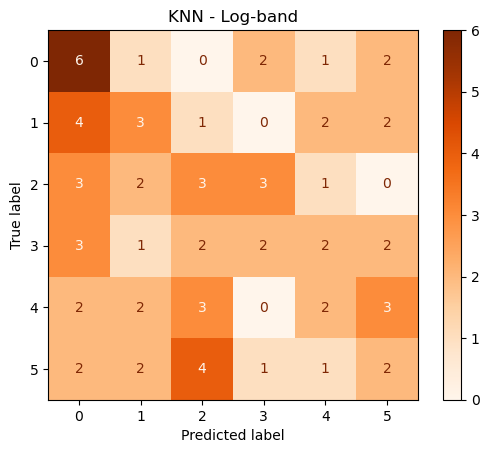

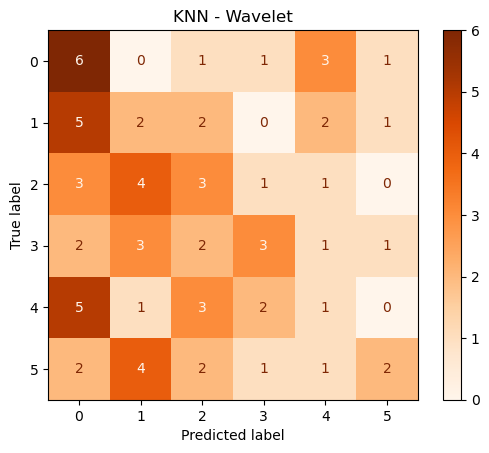

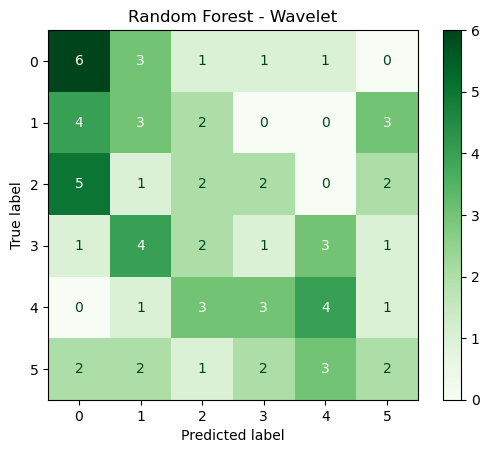

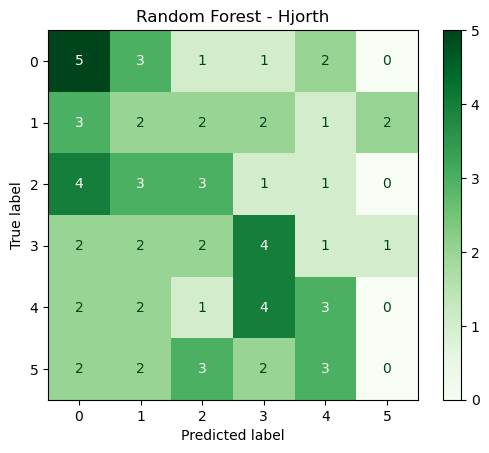

/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


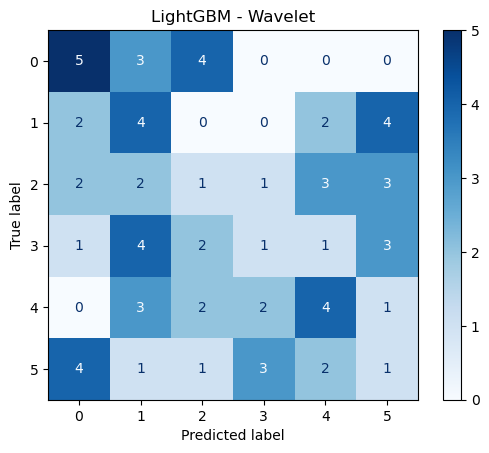

/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


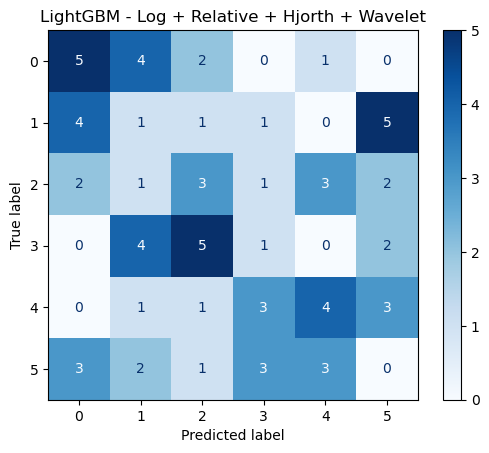

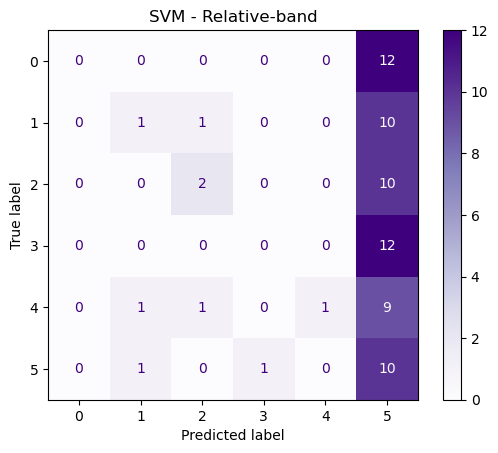

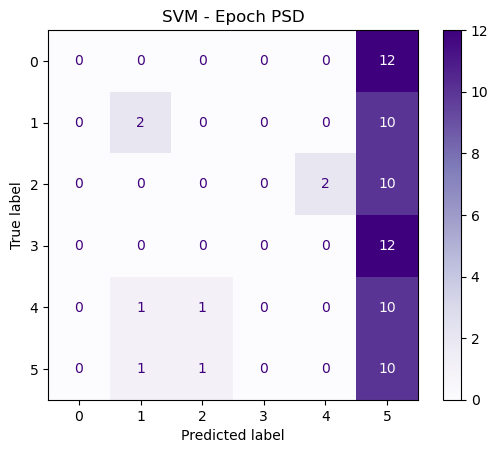

In [19]:

# Ajuste conforme o nome do seu vetor y_test para cada feature set.
# Aqui assumimos y_epoch_test para todos, mas se for diferente troque pelo correto.

for model_name, top2, models_dict, X_tests in [
    ('KNN', top2_knn, models_knn, {
        'Epoch': X_epoch_test,
        'Epoch PSD': X_epoch_psd_test,
        'Log-band': X_epoch_logband_test,
        'Wavelet': X_epoch_wavelet_test,
        'Relative-band': X_epoch_relative_test,
        'Hjorth': X_epoch_hjorth_test,
        'Log + Relative + Hjorth': X_epoch_log_relative_hjorth_test,
        'Log + Relative + Hjorth + Wavelet': X_epoch_log_relative_hjorth_wavelet_test,
    }),
    ('Random Forest', top2_rf, models_rf, {
        'Epoch': X_epoch_test,
        'Epoch PSD': X_epoch_psd_test,
        'Log-band': X_epoch_logband_test,
        'Wavelet': X_epoch_wavelet_test,
        'Relative-band': X_epoch_relative_test,
        'Hjorth': X_epoch_hjorth_test,
        'Log + Relative + Hjorth': X_epoch_log_relative_hjorth_test,
        'Log + Relative + Hjorth + Wavelet': X_epoch_log_relative_hjorth_wavelet_test,
    }),
    ('LightGBM', top2_lgb, models_lgb, {
        'Epoch': X_epoch_test,
        'Epoch PSD': X_epoch_psd_test,
        'Log-band': X_epoch_logband_test,
        'Wavelet': X_epoch_wavelet_test,
        'Relative-band': X_epoch_relative_test,
        'Hjorth': X_epoch_hjorth_test,
        'Log + Relative + Hjorth': X_epoch_log_relative_hjorth_test,
        'Log + Relative + Hjorth + Wavelet': X_epoch_log_relative_hjorth_wavelet_test,
    }),
    ('SVM', top2_svm, models_svm, {
        'Epoch': X_epoch_test,
        'Epoch PSD': X_epoch_psd_test,
        'Log-band': X_epoch_logband_test,
        'Wavelet': X_epoch_wavelet_test,
        'Relative-band': X_epoch_relative_test,
        'Hjorth': X_epoch_hjorth_test,
        'Log + Relative + Hjorth': X_epoch_log_relative_hjorth_test,
        'Log + Relative + Hjorth + Wavelet': X_epoch_log_relative_hjorth_wavelet_test,
    })
]:
    for feat in top2:
        model = models_dict[feat]
        X_test = X_tests[feat]
        # Supondo sempre y_epoch_test como target, ajuste se for diferente!
        y_pred = model.predict(X_test)
        cm = confusion_matrix(y_epoch_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        cmap = {
            'KNN': "Oranges",
            'Random Forest': "Greens",
            'LightGBM': "Blues",
            'SVM': "Purples"
        }[model_name]
        disp.plot(cmap=cmap)
        plt.title(f"{model_name} - {feat}")
        plt.show()

# --- Step 1: Imports, parameters and file listing ---


In [20]:

import pandas as pd
import numpy as np
import mne
from tqdm.notebook import tqdm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.metrics import accuracy_score
from pathlib import Path
import pywt

# Parameters for epoching and bands
EPOCH_LEN = 2.0
EPOCH_STEP = 0.5
FREQ_BANDS = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 50),
}

# List all blocks
data_folder = Path('../bids_dataset/derivatives/annotated')
block_files = sorted(list(data_folder.glob('blk*_annot_raw.fif')))
print("N blocks found:", len(block_files))


N blocks found: 20


# --- Step 2: Helper functions ---


In [21]:

def compute_hjorth(epoch):
    def hjorth_params(x):
        dx = np.diff(x)
        ddx = np.diff(dx)
        var_zero = np.var(x)
        var_d1 = np.var(dx)
        var_d2 = np.var(ddx)
        mobility = np.sqrt(var_d1 / var_zero) if var_zero > 0 else 0
        complexity = np.sqrt(var_d2 / var_d1) / mobility if var_d1 > 0 and mobility > 0 else 0
        return var_zero, mobility, complexity
    return np.array([hjorth_params(ch) for ch in epoch])

def wavelet_energy_features(epoch, wavelet='db4', level=3):
    wp = pywt.WaveletPacket(data=epoch, wavelet=wavelet, mode='symmetric', maxlevel=level)
    nodes = wp.get_level(level, order='freq')
    energies = np.array([np.sum(np.square(n.data)) for n in nodes])
    return energies


# --- Step 3: Scan for all global phrase labels and map to numbers ---

In [22]:

all_phrase_labels = []
for fif_file in tqdm(block_files, desc="Scanning labels"):
    try:
        raw = mne.io.read_raw_fif(fif_file, preload=False, verbose=False)
        events, event_ids = mne.events_from_annotations(raw, verbose=False)
        id_to_desc = {v: k for k, v in event_ids.items()}
        for e in events:
            if id_to_desc.get(e[2], "").startswith('phrase/'):
                all_phrase_labels.append(e[2])
    except Exception as e:
        print(f"Error in {fif_file.name}: {e}")

unique_labels = sorted(np.unique(all_phrase_labels))
label_map = {ev: ix+1 for ix, ev in enumerate(unique_labels)}
print("Global label map:", label_map)


Scanning labels:   0%|          | 0/20 [00:00<?, ?it/s]

Global label map: {np.int64(1): 1, np.int64(2): 2, np.int64(3): 3, np.int64(4): 4, np.int64(5): 5, np.int64(6): 6}


# --- Step 4: Função de extração de features para uma lista de blocos ---


In [23]:

def extract_wavelet_features(block_list, label_map, desc=""):
    features, labels = [], []
    for fif_file in tqdm(block_list, desc=f"Extracting features {desc}"):
        try:
            raw = mne.io.read_raw_fif(fif_file, preload=True, verbose=False)
            sfreq = raw.info['sfreq']
            events, event_ids = mne.events_from_annotations(raw, verbose=False)
            id_to_desc = {v: k for k, v in event_ids.items()}
            # Selecionar eventos do tipo phrase
            phrase_event_ids = {desc:eid for desc,eid in event_ids.items() if desc.startswith('phrase/')}
            if not phrase_event_ids: continue
            epochs = mne.Epochs(
                raw, events, event_id=phrase_event_ids, tmin=0, tmax=EPOCH_LEN, baseline=None,
                preload=True, detrend=1, picks='eeg', verbose=False)
            if len(epochs) == 0: continue
            epoch_data = epochs.get_data(copy=False)
            for i, ep in enumerate(epoch_data):
                label = epochs.events[i, 2]
                if label not in label_map: continue
                n_samples = ep.shape[1]
                win_len = int(EPOCH_LEN * sfreq)
                step = int(EPOCH_STEP * sfreq)
                for start in range(0, n_samples-win_len+1, step):
                    chunk = ep[:, start:start+win_len]
                    if chunk.shape[1] == 0: continue
                    feat_wav = []
                    for ch_data in chunk:
                        energies = wavelet_energy_features(ch_data, wavelet='db4', level=3)
                        feat_wav.extend(energies)
                    features.append(feat_wav)
                    labels.append(label)
        except Exception as e:
            print(f"Error in {fif_file.name}: {e}")
    # Output: numpy arrays
    X = np.vstack(features) if features else np.empty((0,0))
    y = np.array([label_map[x] for x in labels])
    return X, y


# --- Step 5: Leave-One-Block-Out (LOBO) com KNN, RF, LightGBM ---


In [24]:

results_lobo = []

for i, held_out_block in enumerate(block_files):
    print(f"\nFold {i+1}/{len(block_files)}: Teste em {held_out_block.name}")

    # Split train/test por bloco
    train_blocks = [f for f in block_files if f != held_out_block]
    test_blocks = [held_out_block]

    # Extrair features
    X_train, y_train = extract_wavelet_features(train_blocks, label_map, desc="(train)")
    X_test, y_test   = extract_wavelet_features(test_blocks,  label_map, desc="(test)")

    if X_train.shape[0] == 0 or X_test.shape[0] == 0:
        print("Sem dados para esse fold, pulando...")
        results_lobo.append({
            'block': held_out_block.name,
            'knn_acc': np.nan,
            'rf_acc': np.nan,
            'lgbm_acc': np.nan
        })
        continue

    # Ajustar número de vizinhos se necessário
    n_neighbors = min(5, X_train.shape[0])

    # --- KNN ---
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    knn.fit(X_train, y_train)
    y_pred_knn = knn.predict(X_test)
    acc_knn = accuracy_score(y_test, y_pred_knn)

    # --- Random Forest ---
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    acc_rf = accuracy_score(y_test, y_pred_rf)

    # --- LightGBM ---
    lgbm = lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
    lgbm.fit(X_train, y_train)
    y_pred_lgbm = lgbm.predict(X_test)
    acc_lgbm = accuracy_score(y_test, y_pred_lgbm)

    results_lobo.append({
        'block': held_out_block.name,
        'knn_acc': acc_knn,
        'rf_acc': acc_rf,
        'lgbm_acc': acc_lgbm
    })

    print(f"Acurácias - KNN: {acc_knn:.3f} | RF: {acc_rf:.3f} | LGBM: {acc_lgbm:.3f} (n_test={len(y_test)})")

# Salvar resultados em DataFrame
df_lobo = pd.DataFrame(results_lobo)
print("\nResumo Leave-One-Block-Out (Wavelet):")
display(df_lobo)
print("\nMédia das acurácias LOBO:")
print("KNN  :", df_lobo['knn_acc'].mean())
print("RF   :", df_lobo['rf_acc'].mean())
print("LGBM :", df_lobo['lgbm_acc'].mean())



Fold 1/20: Teste em blk00_annot_raw.fif


Extracting features (train):   0%|          | 0/19 [00:00<?, ?it/s]

Extracting features (test):   0%|          | 0/1 [00:00<?, ?it/s]

Acurácias - KNN: 0.167 | RF: 0.111 | LGBM: 0.167 (n_test=18)

Fold 2/20: Teste em blk01_annot_raw.fif


/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

Extracting features (test):   0%|          | 0/1 [00:00<?, ?it/s]

Acurácias - KNN: 0.222 | RF: 0.167 | LGBM: 0.167 (n_test=18)

Resumo Leave-One-Block-Out (Wavelet):


/opt/homebrew/Caskroom/miniforge/base/envs/creativity-eeg/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,block,knn_acc,rf_acc,lgbm_acc
0,blk00_annot_raw.fif,0.166667,0.111111,0.166667
1,blk01_annot_raw.fif,0.111111,0.111111,0.222222
2,blk02_annot_raw.fif,0.222222,0.166667,0.222222
3,blk03_annot_raw.fif,0.166667,0.111111,0.222222
4,blk04_annot_raw.fif,0.166667,0.277778,0.222222
5,blk05_annot_raw.fif,0.111111,0.333333,0.277778
6,blk06_annot_raw.fif,0.055556,0.277778,0.055556
7,blk07_annot_raw.fif,0.222222,0.388889,0.222222
8,blk08_annot_raw.fif,0.166667,0.222222,0.277778
9,blk09_annot_raw.fif,0.166667,0.222222,0.111111



Média das acurácias LOBO:
KNN  : 0.18888888888888888
RF   : 0.21666666666666665
LGBM : 0.2111111111111111




====== Comparando blk06_annot_raw.fif vs blk18_annot_raw.fif ======


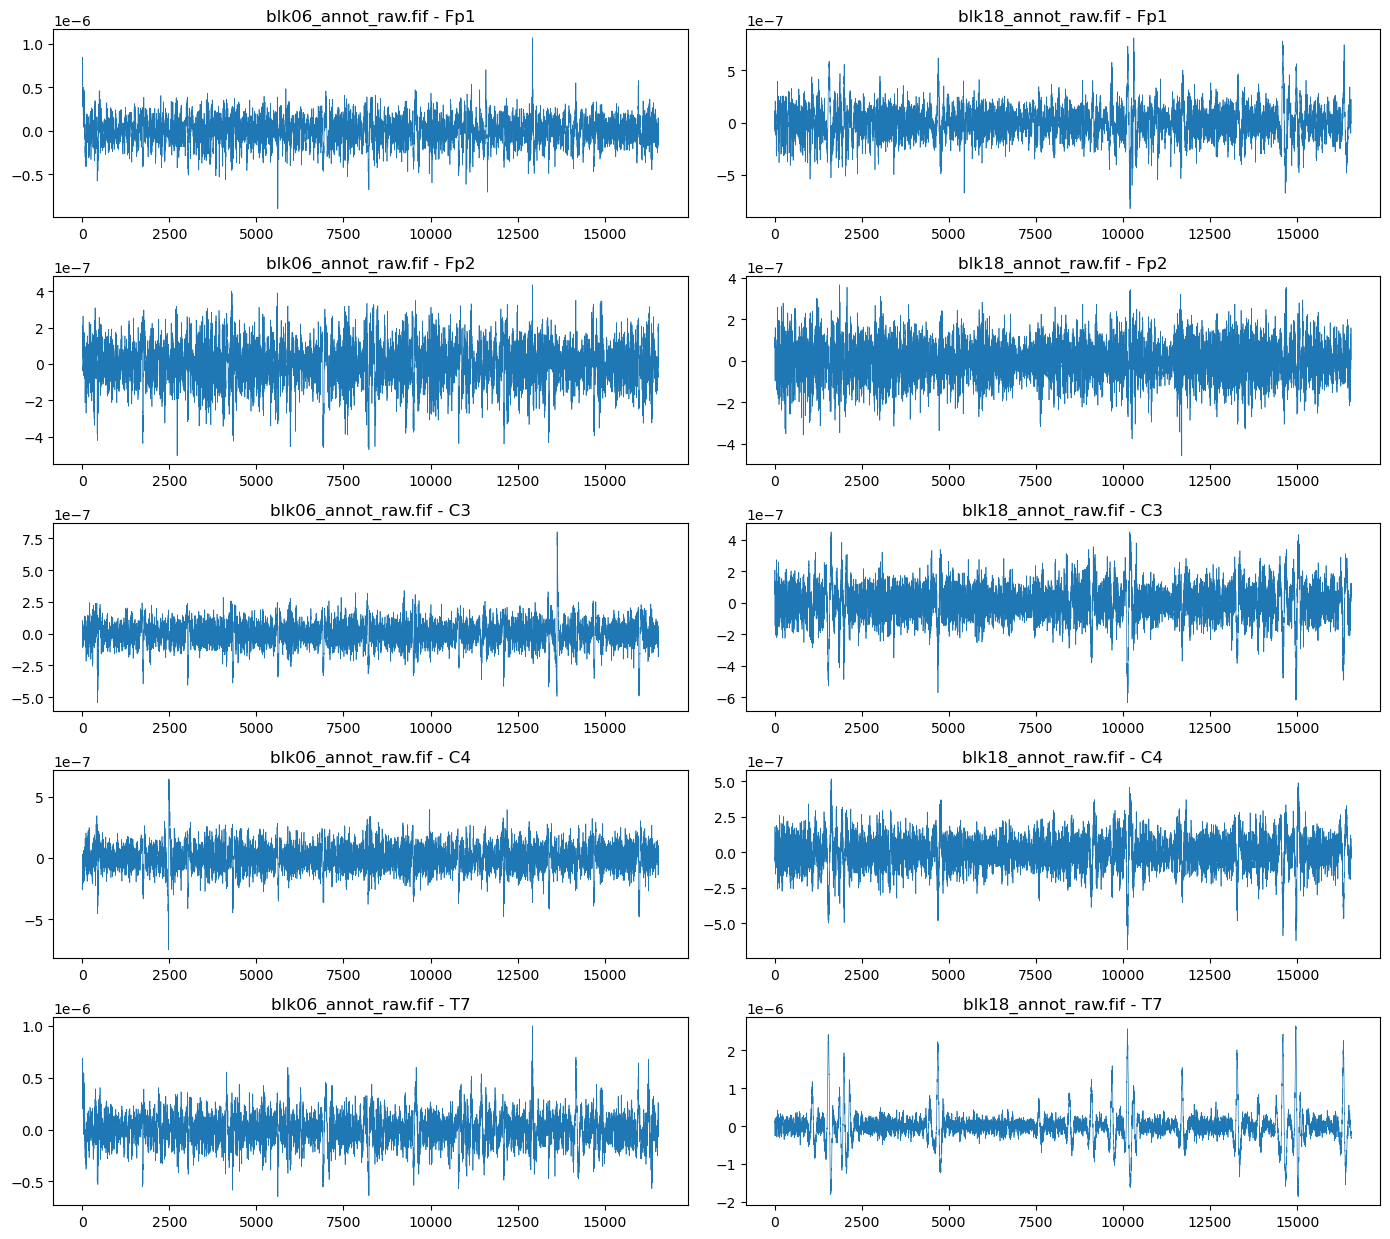

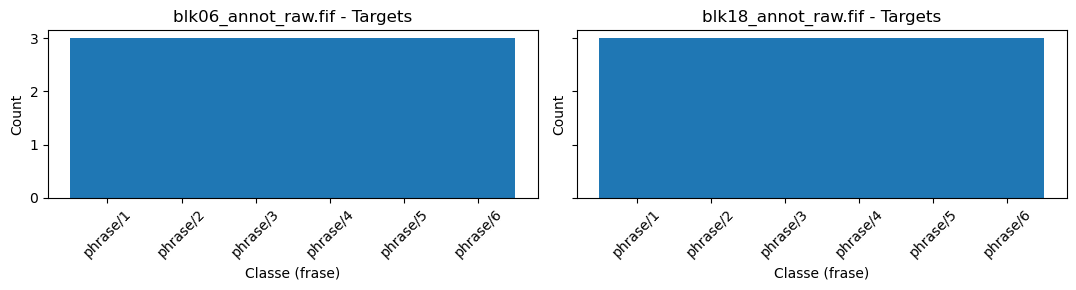


Estatísticas blk06_annot_raw.fif:
Fp1  : mean=0.0, std=0.0, SNR=0.01
Fp2  : mean=0.0, std=0.0, SNR=0.01
C3   : mean=-0.0, std=0.0, SNR=-0.00
C4   : mean=-0.0, std=0.0, SNR=-0.00
T7   : mean=0.0, std=0.0, SNR=0.00
T8   : mean=-0.0, std=0.0, SNR=-0.00
O1   : mean=-0.0, std=0.0, SNR=-0.00
O2   : mean=-0.0, std=0.0, SNR=-0.00
F3   : mean=0.0, std=0.0, SNR=0.00
F4   : mean=-0.0, std=0.0, SNR=-0.00
Fz   : mean=-0.0, std=0.0, SNR=-0.00
Pz   : mean=-0.0, std=0.0, SNR=-0.00
P3   : mean=-0.0, std=0.0, SNR=-0.00
P4   : mean=-0.0, std=0.0, SNR=-0.00
----------------------------
Estatísticas blk18_annot_raw.fif:
Fp1  : mean=0.0, std=0.0, SNR=0.01
Fp2  : mean=0.0, std=0.0, SNR=0.02
C3   : mean=-0.0, std=0.0, SNR=-0.00
C4   : mean=-0.0, std=0.0, SNR=-0.00
T7   : mean=-0.0, std=0.0, SNR=-0.00
T8   : mean=-0.0, std=0.0, SNR=-0.00
O1   : mean=0.0, std=0.0, SNR=0.00
O2   : mean=-0.0, std=0.0, SNR=-0.00
F3   : mean=-0.0, std=0.0, SNR=-0.00
F4   : mean=-0.0, std=0.0, SNR=-0.00
Fz   : mean=-0.0, std=0.0, S

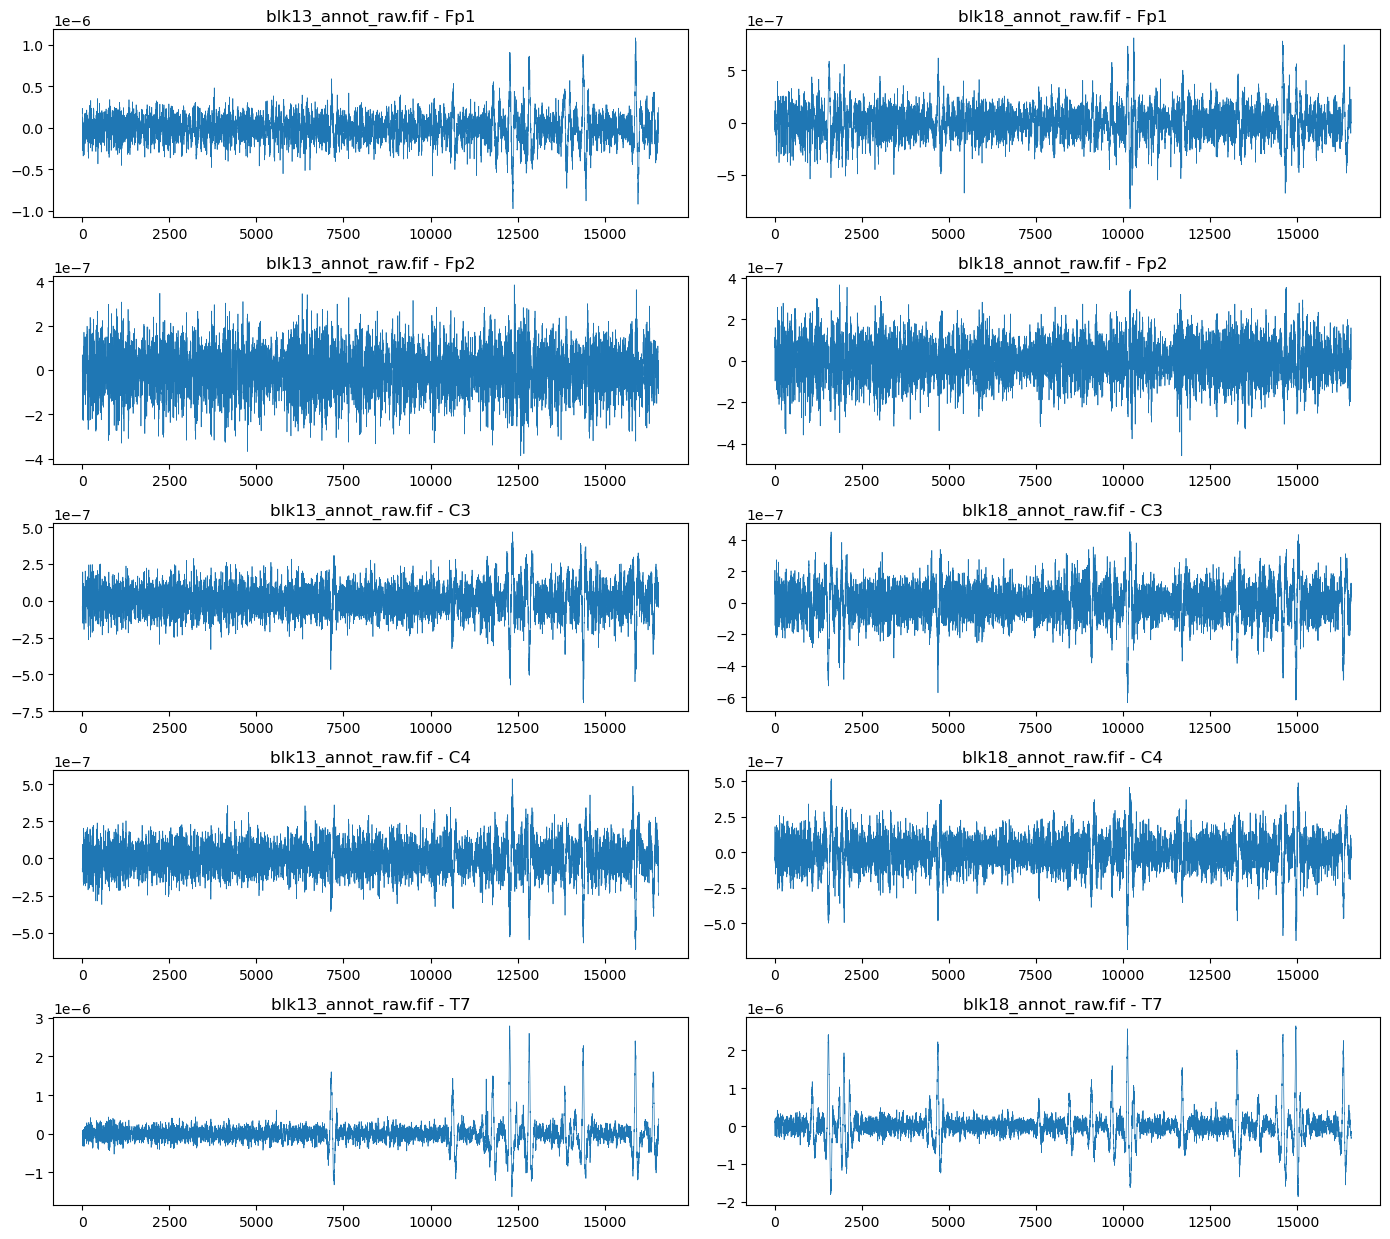

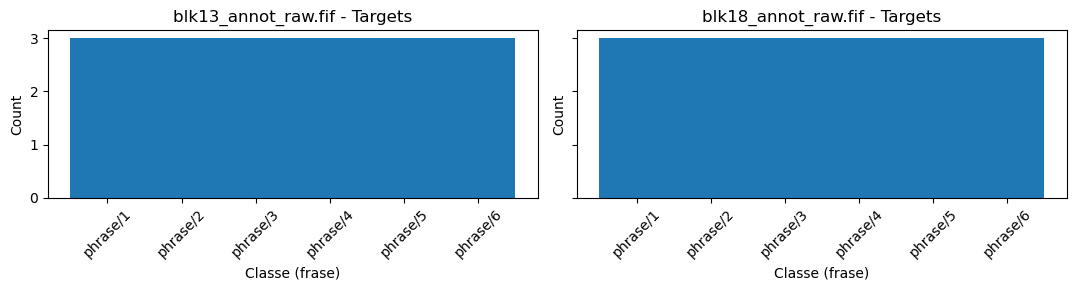


Estatísticas blk13_annot_raw.fif:
Fp1  : mean=-0.0, std=0.0, SNR=-0.02
Fp2  : mean=-0.0, std=0.0, SNR=-0.03
C3   : mean=0.0, std=0.0, SNR=0.00
C4   : mean=0.0, std=0.0, SNR=0.00
T7   : mean=-0.0, std=0.0, SNR=-0.00
T8   : mean=0.0, std=0.0, SNR=0.00
O1   : mean=0.0, std=0.0, SNR=0.00
O2   : mean=0.0, std=0.0, SNR=0.00
F3   : mean=-0.0, std=0.0, SNR=-0.00
F4   : mean=0.0, std=0.0, SNR=0.00
Fz   : mean=0.0, std=0.0, SNR=0.00
Pz   : mean=0.0, std=0.0, SNR=0.00
P3   : mean=0.0, std=0.0, SNR=0.01
P4   : mean=0.0, std=0.0, SNR=0.01
----------------------------
Estatísticas blk18_annot_raw.fif:
Fp1  : mean=0.0, std=0.0, SNR=0.01
Fp2  : mean=0.0, std=0.0, SNR=0.02
C3   : mean=-0.0, std=0.0, SNR=-0.00
C4   : mean=-0.0, std=0.0, SNR=-0.00
T7   : mean=-0.0, std=0.0, SNR=-0.00
T8   : mean=-0.0, std=0.0, SNR=-0.00
O1   : mean=0.0, std=0.0, SNR=0.00
O2   : mean=-0.0, std=0.0, SNR=-0.00
F3   : mean=-0.0, std=0.0, SNR=-0.00
F4   : mean=-0.0, std=0.0, SNR=-0.00
Fz   : mean=-0.0, std=0.0, SNR=-0.00
Pz 

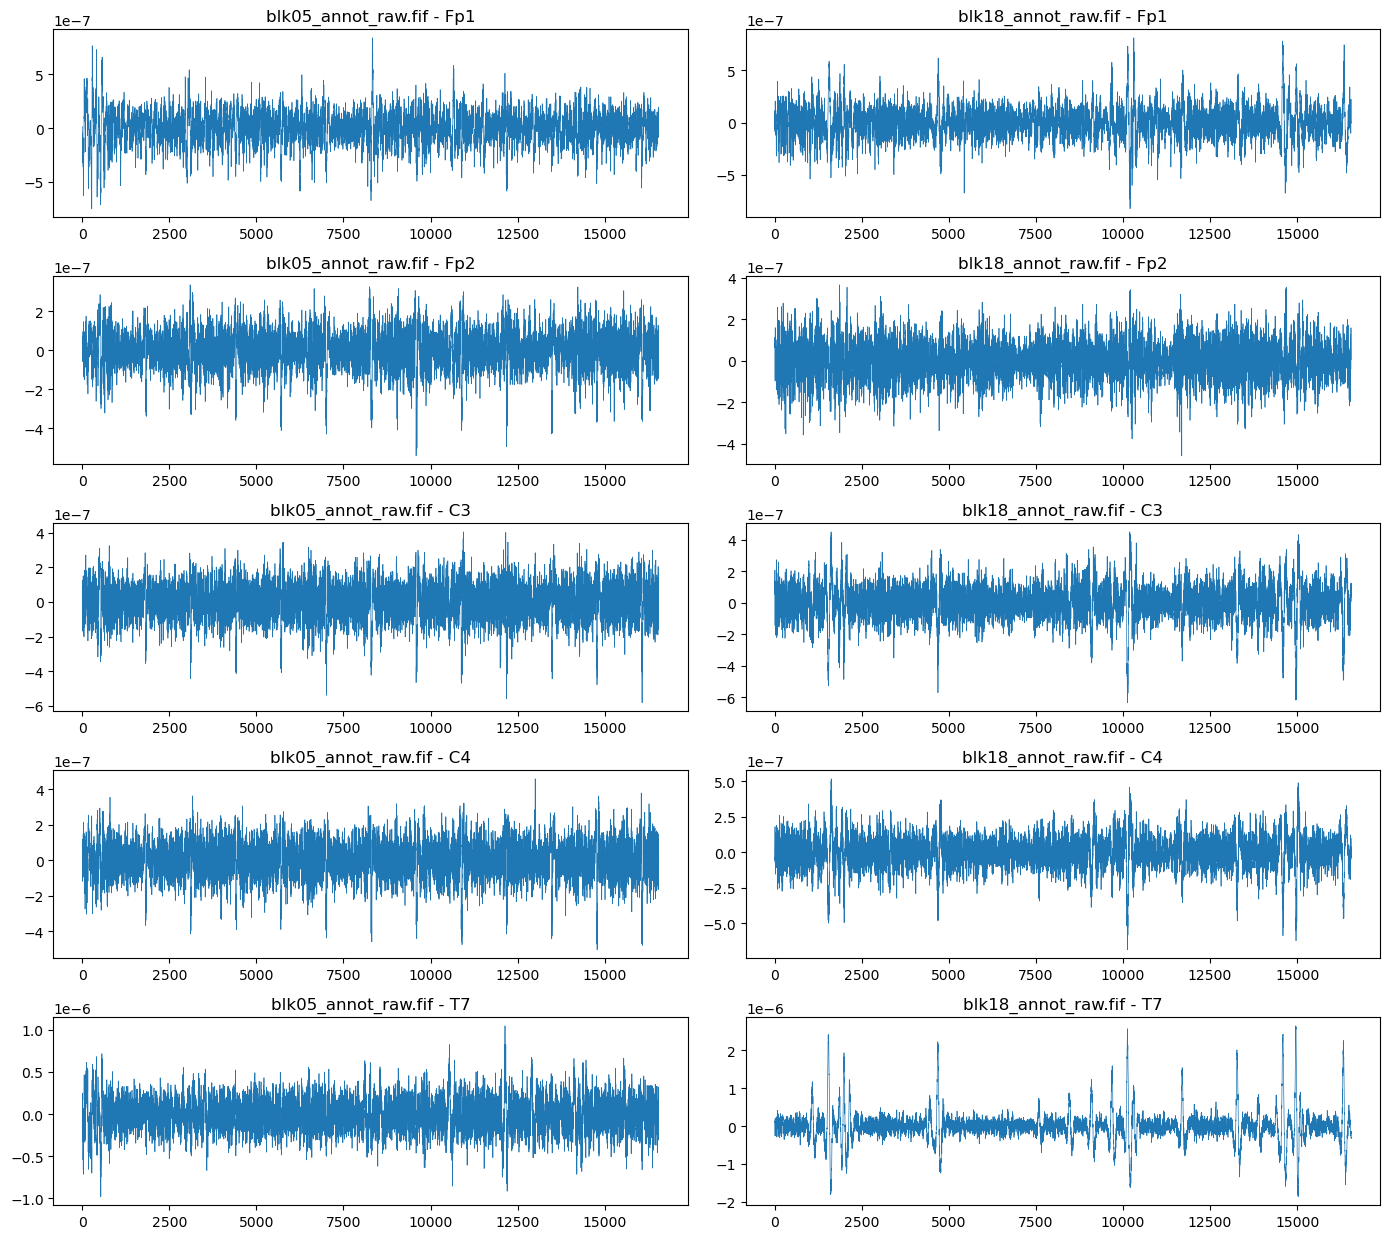

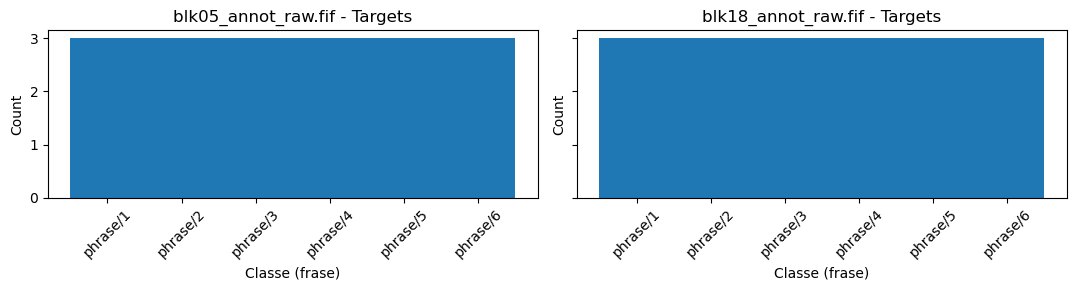


Estatísticas blk05_annot_raw.fif:
Fp1  : mean=0.0, std=0.0, SNR=0.00
Fp2  : mean=0.0, std=0.0, SNR=0.01
C3   : mean=-0.0, std=0.0, SNR=-0.00
C4   : mean=-0.0, std=0.0, SNR=-0.00
T7   : mean=-0.0, std=0.0, SNR=-0.00
T8   : mean=0.0, std=0.0, SNR=0.00
O1   : mean=-0.0, std=0.0, SNR=-0.00
O2   : mean=0.0, std=0.0, SNR=0.00
F3   : mean=-0.0, std=0.0, SNR=-0.00
F4   : mean=0.0, std=0.0, SNR=0.00
Fz   : mean=-0.0, std=0.0, SNR=-0.00
Pz   : mean=-0.0, std=0.0, SNR=-0.00
P3   : mean=-0.0, std=0.0, SNR=-0.00
P4   : mean=-0.0, std=0.0, SNR=-0.00
----------------------------
Estatísticas blk18_annot_raw.fif:
Fp1  : mean=0.0, std=0.0, SNR=0.01
Fp2  : mean=0.0, std=0.0, SNR=0.02
C3   : mean=-0.0, std=0.0, SNR=-0.00
C4   : mean=-0.0, std=0.0, SNR=-0.00
T7   : mean=-0.0, std=0.0, SNR=-0.00
T8   : mean=-0.0, std=0.0, SNR=-0.00
O1   : mean=0.0, std=0.0, SNR=0.00
O2   : mean=-0.0, std=0.0, SNR=-0.00
F3   : mean=-0.0, std=0.0, SNR=-0.00
F4   : mean=-0.0, std=0.0, SNR=-0.00
Fz   : mean=-0.0, std=0.0, SNR

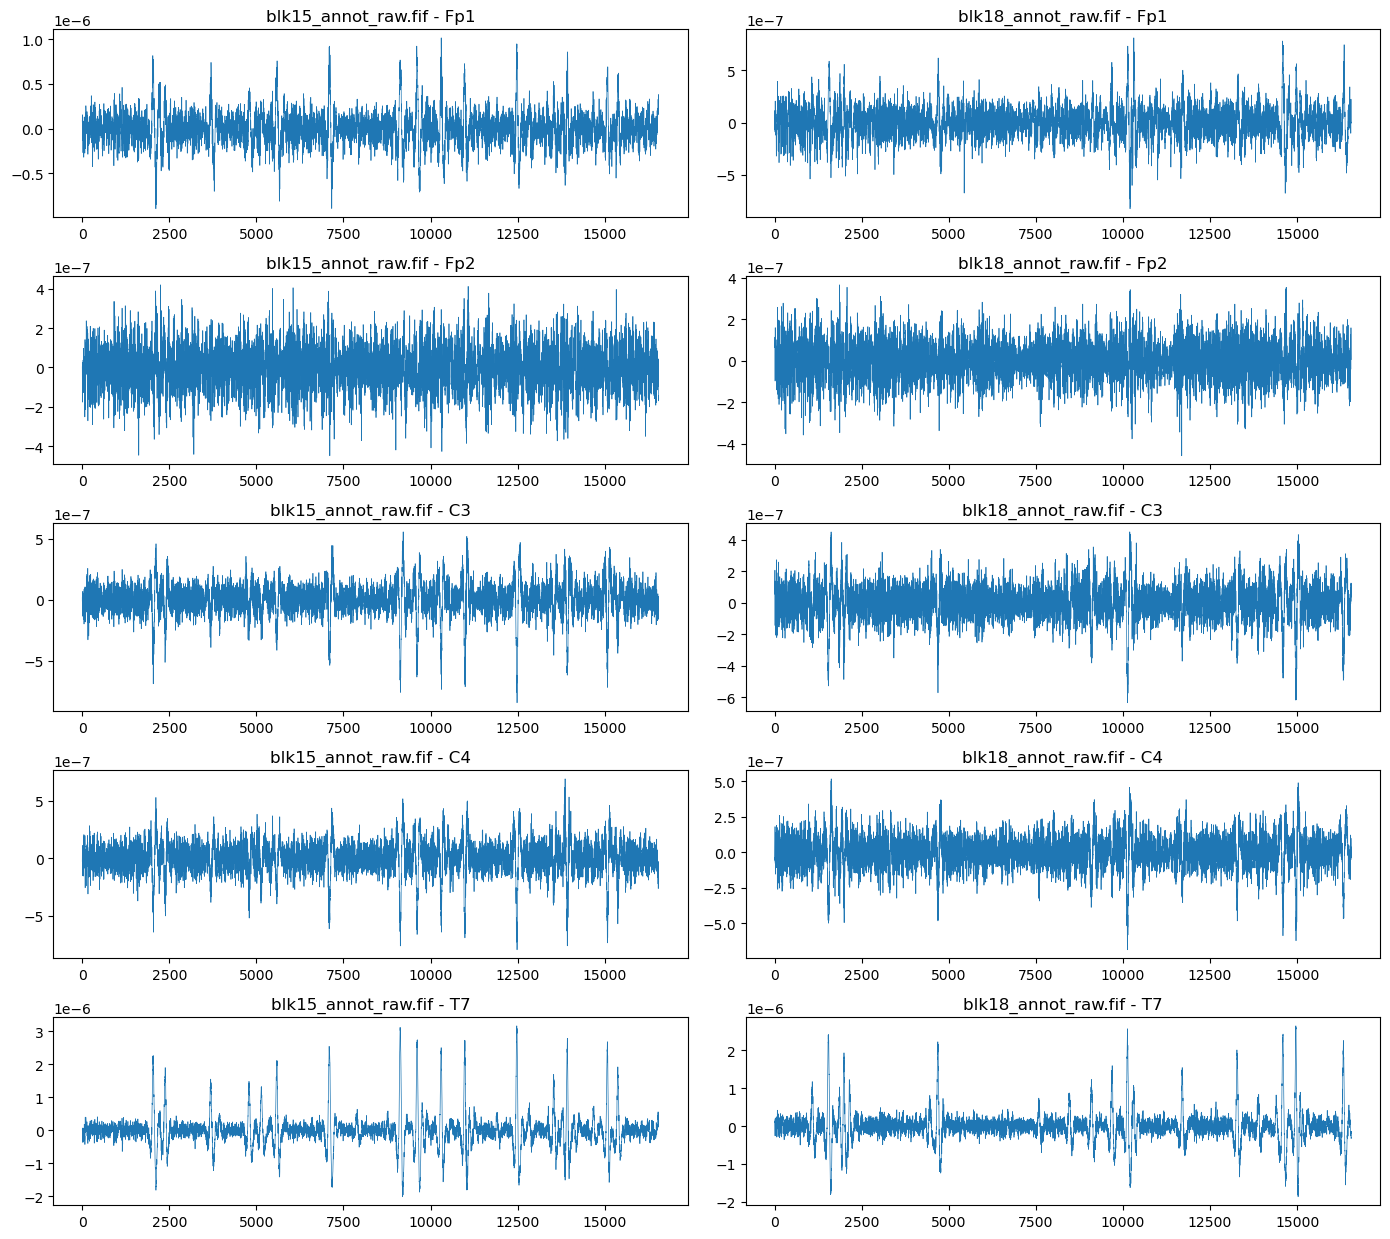

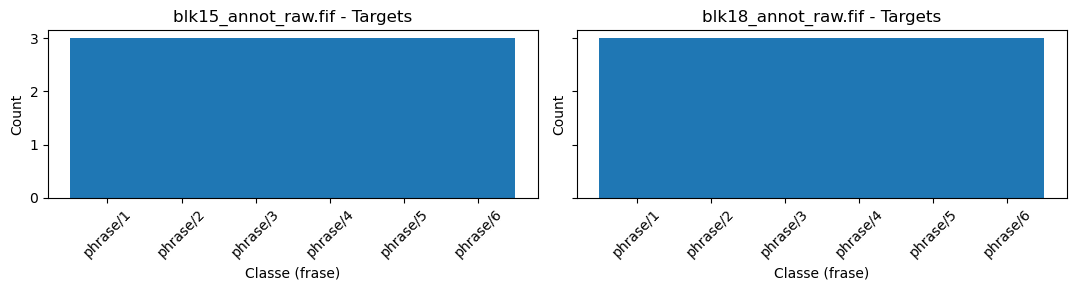


Estatísticas blk15_annot_raw.fif:
Fp1  : mean=0.0, std=0.0, SNR=0.01
Fp2  : mean=0.0, std=0.0, SNR=0.02
C3   : mean=-0.0, std=0.0, SNR=-0.00
C4   : mean=-0.0, std=0.0, SNR=-0.00
T7   : mean=0.0, std=0.0, SNR=0.00
T8   : mean=0.0, std=0.0, SNR=0.00
O1   : mean=-0.0, std=0.0, SNR=-0.00
O2   : mean=-0.0, std=0.0, SNR=-0.00
F3   : mean=-0.0, std=0.0, SNR=-0.00
F4   : mean=-0.0, std=0.0, SNR=-0.00
Fz   : mean=-0.0, std=0.0, SNR=-0.00
Pz   : mean=-0.0, std=0.0, SNR=-0.00
P3   : mean=-0.0, std=0.0, SNR=-0.00
P4   : mean=-0.0, std=0.0, SNR=-0.00
----------------------------
Estatísticas blk18_annot_raw.fif:
Fp1  : mean=0.0, std=0.0, SNR=0.01
Fp2  : mean=0.0, std=0.0, SNR=0.02
C3   : mean=-0.0, std=0.0, SNR=-0.00
C4   : mean=-0.0, std=0.0, SNR=-0.00
T7   : mean=-0.0, std=0.0, SNR=-0.00
T8   : mean=-0.0, std=0.0, SNR=-0.00
O1   : mean=0.0, std=0.0, SNR=0.00
O2   : mean=-0.0, std=0.0, SNR=-0.00
F3   : mean=-0.0, std=0.0, SNR=-0.00
F4   : mean=-0.0, std=0.0, SNR=-0.00
Fz   : mean=-0.0, std=0.0, S

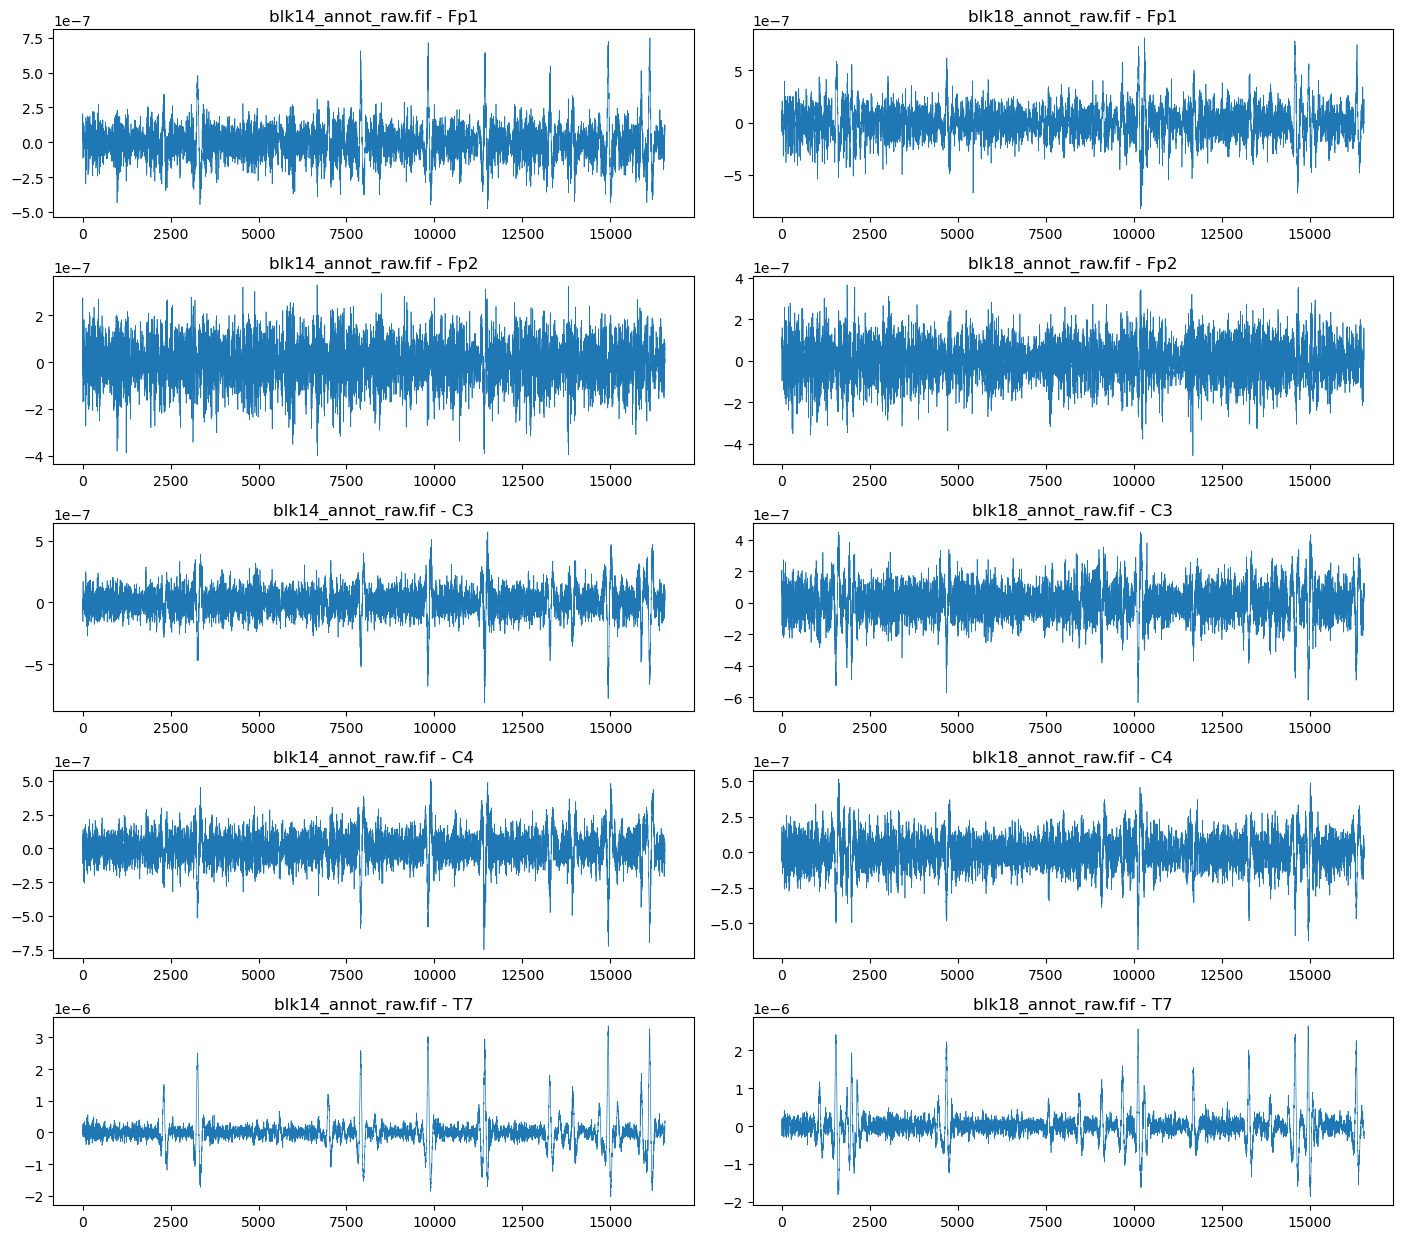

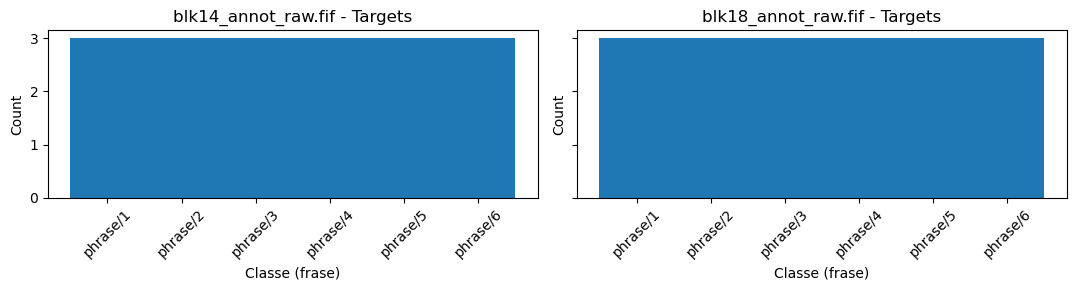


Estatísticas blk14_annot_raw.fif:
Fp1  : mean=0.0, std=0.0, SNR=0.01
Fp2  : mean=0.0, std=0.0, SNR=0.01
C3   : mean=-0.0, std=0.0, SNR=-0.00
C4   : mean=-0.0, std=0.0, SNR=-0.00
T7   : mean=0.0, std=0.0, SNR=0.00
T8   : mean=0.0, std=0.0, SNR=0.00
O1   : mean=-0.0, std=0.0, SNR=-0.00
O2   : mean=0.0, std=0.0, SNR=0.00
F3   : mean=-0.0, std=0.0, SNR=-0.00
F4   : mean=-0.0, std=0.0, SNR=-0.00
Fz   : mean=-0.0, std=0.0, SNR=-0.00
Pz   : mean=-0.0, std=0.0, SNR=-0.00
P3   : mean=-0.0, std=0.0, SNR=-0.00
P4   : mean=-0.0, std=0.0, SNR=-0.00
----------------------------
Estatísticas blk18_annot_raw.fif:
Fp1  : mean=0.0, std=0.0, SNR=0.01
Fp2  : mean=0.0, std=0.0, SNR=0.02
C3   : mean=-0.0, std=0.0, SNR=-0.00
C4   : mean=-0.0, std=0.0, SNR=-0.00
T7   : mean=-0.0, std=0.0, SNR=-0.00
T8   : mean=-0.0, std=0.0, SNR=-0.00
O1   : mean=0.0, std=0.0, SNR=0.00
O2   : mean=-0.0, std=0.0, SNR=-0.00
F3   : mean=-0.0, std=0.0, SNR=-0.00
F4   : mean=-0.0, std=0.0, SNR=-0.00
Fz   : mean=-0.0, std=0.0, SNR

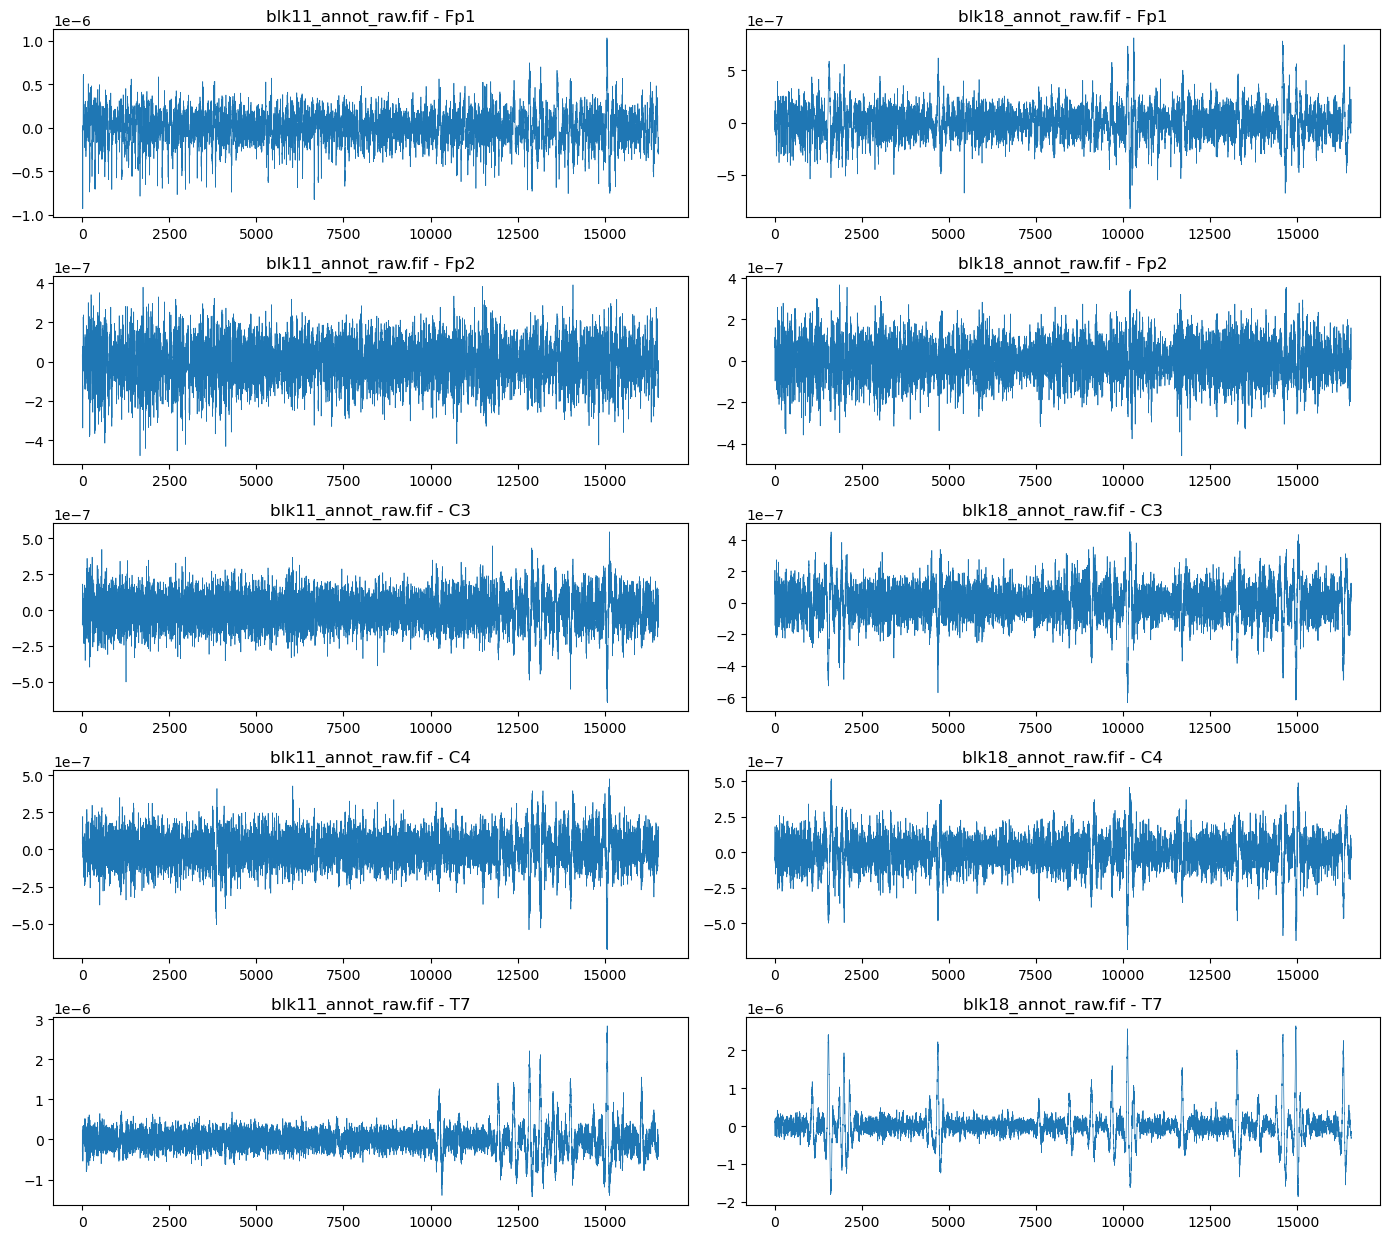

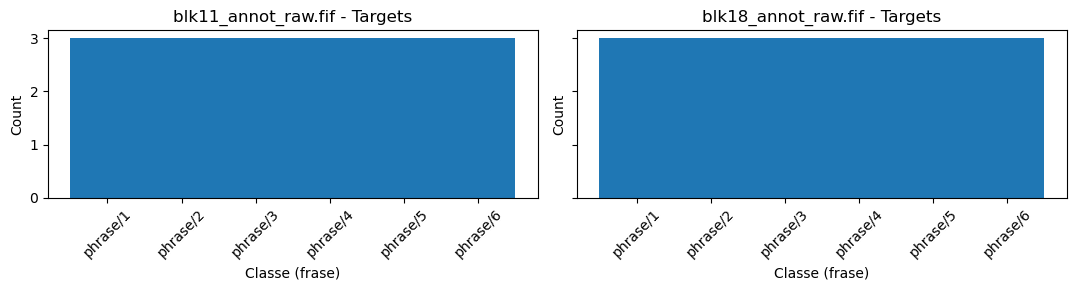


Estatísticas blk11_annot_raw.fif:
Fp1  : mean=-0.0, std=0.0, SNR=-0.01
Fp2  : mean=-0.0, std=0.0, SNR=-0.02
C3   : mean=0.0, std=0.0, SNR=0.00
C4   : mean=0.0, std=0.0, SNR=0.00
T7   : mean=0.0, std=0.0, SNR=0.00
T8   : mean=0.0, std=0.0, SNR=0.00
O1   : mean=0.0, std=0.0, SNR=0.00
O2   : mean=0.0, std=0.0, SNR=0.00
F3   : mean=-0.0, std=0.0, SNR=-0.00
F4   : mean=0.0, std=0.0, SNR=0.00
Fz   : mean=-0.0, std=0.0, SNR=-0.00
Pz   : mean=0.0, std=0.0, SNR=0.00
P3   : mean=0.0, std=0.0, SNR=0.00
P4   : mean=0.0, std=0.0, SNR=0.00
----------------------------
Estatísticas blk18_annot_raw.fif:
Fp1  : mean=0.0, std=0.0, SNR=0.01
Fp2  : mean=0.0, std=0.0, SNR=0.02
C3   : mean=-0.0, std=0.0, SNR=-0.00
C4   : mean=-0.0, std=0.0, SNR=-0.00
T7   : mean=-0.0, std=0.0, SNR=-0.00
T8   : mean=-0.0, std=0.0, SNR=-0.00
O1   : mean=0.0, std=0.0, SNR=0.00
O2   : mean=-0.0, std=0.0, SNR=-0.00
F3   : mean=-0.0, std=0.0, SNR=-0.00
F4   : mean=-0.0, std=0.0, SNR=-0.00
Fz   : mean=-0.0, std=0.0, SNR=-0.00
Pz 

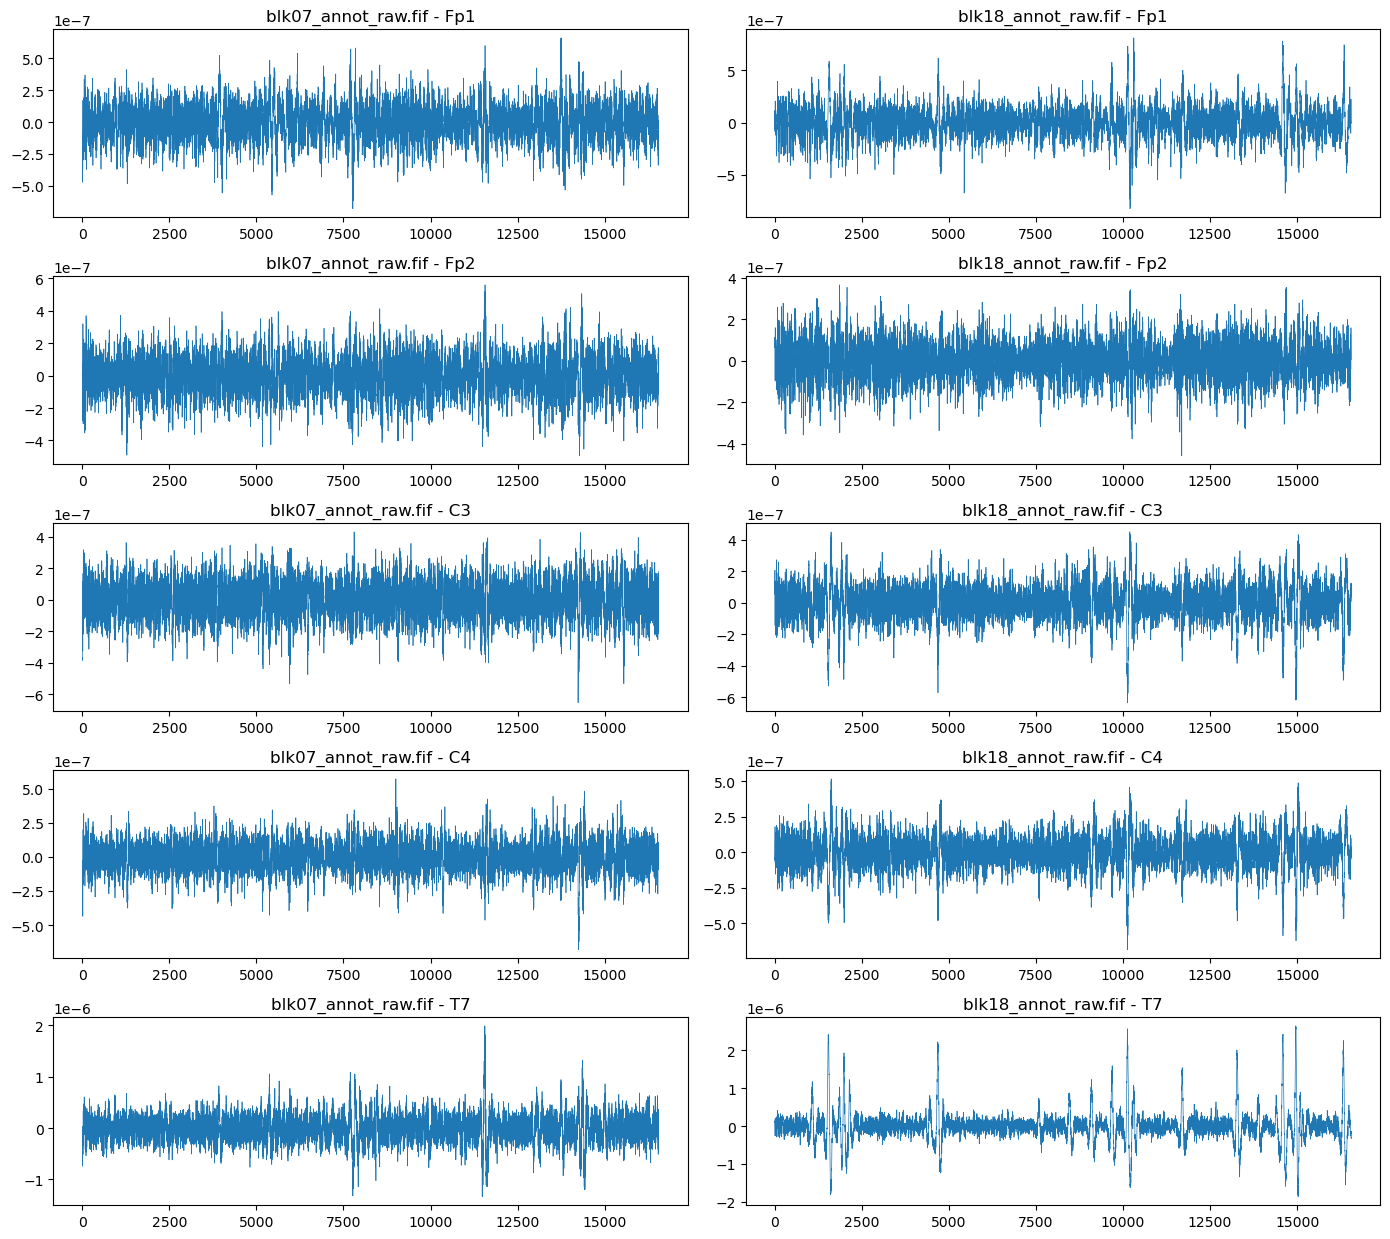

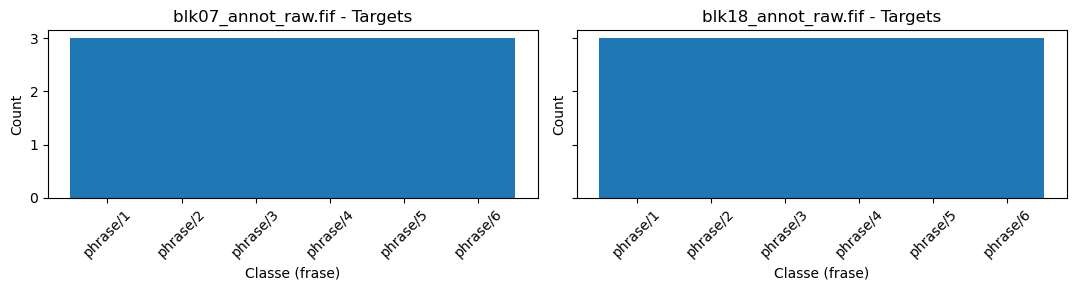


Estatísticas blk07_annot_raw.fif:
Fp1  : mean=0.0, std=0.0, SNR=0.01
Fp2  : mean=0.0, std=0.0, SNR=0.01
C3   : mean=-0.0, std=0.0, SNR=-0.00
C4   : mean=-0.0, std=0.0, SNR=-0.00
T7   : mean=-0.0, std=0.0, SNR=-0.00
T8   : mean=0.0, std=0.0, SNR=0.00
O1   : mean=0.0, std=0.0, SNR=0.00
O2   : mean=-0.0, std=0.0, SNR=-0.00
F3   : mean=-0.0, std=0.0, SNR=-0.00
F4   : mean=-0.0, std=0.0, SNR=-0.00
Fz   : mean=-0.0, std=0.0, SNR=-0.00
Pz   : mean=-0.0, std=0.0, SNR=-0.00
P3   : mean=-0.0, std=0.0, SNR=-0.00
P4   : mean=-0.0, std=0.0, SNR=-0.00
----------------------------
Estatísticas blk18_annot_raw.fif:
Fp1  : mean=0.0, std=0.0, SNR=0.01
Fp2  : mean=0.0, std=0.0, SNR=0.02
C3   : mean=-0.0, std=0.0, SNR=-0.00
C4   : mean=-0.0, std=0.0, SNR=-0.00
T7   : mean=-0.0, std=0.0, SNR=-0.00
T8   : mean=-0.0, std=0.0, SNR=-0.00
O1   : mean=0.0, std=0.0, SNR=0.00
O2   : mean=-0.0, std=0.0, SNR=-0.00
F3   : mean=-0.0, std=0.0, SNR=-0.00
F4   : mean=-0.0, std=0.0, SNR=-0.00
Fz   : mean=-0.0, std=0.0, S

In [25]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path

# Blocos suspeitos:
suspect_blocks = [
    "blk06_annot_raw.fif",
    "blk13_annot_raw.fif",
    "blk05_annot_raw.fif",
    "blk15_annot_raw.fif",
    "blk14_annot_raw.fif",
    "blk11_annot_raw.fif",
    "blk07_annot_raw.fif",
]
healthy_block = "blk18_annot_raw.fif"
data_folder = Path("../bids_dataset/derivatives/annotated")

def analyze_block(blk_path):
    raw = mne.io.read_raw_fif(blk_path, preload=True, verbose=False)
    eeg_chs = mne.pick_types(raw.info, eeg=True)
    channels = [raw.ch_names[i] for i in eeg_chs]
    data = raw.get_data(picks=eeg_chs)
    events, event_ids = mne.events_from_annotations(raw, verbose=False)
    id2desc = {v: k for k, v in event_ids.items()}
    target_events = [ev for ev in events if id2desc.get(ev[2], '').startswith('phrase/')]
    targets = [id2desc[ev[2]] for ev in target_events]
    mean_per_ch = data.mean(axis=1)
    std_per_ch = data.std(axis=1)
    snr_per_ch = np.where(std_per_ch != 0, mean_per_ch / std_per_ch, 0)
    return {
        "raw": raw,
        "channels": channels,
        "data": data,
        "targets": targets,
        "mean_per_ch": mean_per_ch,
        "std_per_ch": std_per_ch,
        "snr_per_ch": snr_per_ch
    }

# Pré-carregar bloco saudável
healthy = analyze_block(data_folder / healthy_block)

for blk_name in suspect_blocks:
    suspect = analyze_block(data_folder / blk_name)
    print(f"\n\n====== Comparando {blk_name} vs {healthy_block} ======")

    # 1. Sinais de EEG (primeiros 5 canais para visual limpo, ajuste se quiser mais)
    n_plot_ch = min(5, len(suspect["channels"]))
    fig, axes = plt.subplots(n_plot_ch, 2, figsize=(14, 2.5 * n_plot_ch), sharex=False)
    for i in range(n_plot_ch):
        axes[i, 0].plot(suspect["data"][i], lw=0.5)
        axes[i, 0].set_title(f"{blk_name} - {suspect['channels'][i]}")
        axes[i, 1].plot(healthy["data"][i], lw=0.5)
        axes[i, 1].set_title(f"{healthy_block} - {healthy['channels'][i]}")
    plt.tight_layout()
    plt.show()

    # 2. Histogramas de targets
    suspect_target_labels = sorted(list(set(suspect["targets"])))
    healthy_target_labels = sorted(list(set(healthy["targets"])))
    suspect_bins = np.arange(len(suspect_target_labels)+1) - 0.5
    healthy_bins = np.arange(len(healthy_target_labels)+1) - 0.5

    fig, axes = plt.subplots(1, 2, figsize=(11, 3), sharey=True)
    axes[0].hist([suspect_target_labels.index(t) for t in suspect["targets"]], bins=suspect_bins)
    axes[0].set_title(f"{blk_name} - Targets")
    axes[0].set_xticks(range(len(suspect_target_labels)))
    axes[0].set_xticklabels(suspect_target_labels, rotation=45)

    axes[1].hist([healthy_target_labels.index(t) for t in healthy["targets"]], bins=healthy_bins)
    axes[1].set_title(f"{healthy_block} - Targets")
    axes[1].set_xticks(range(len(healthy_target_labels)))
    axes[1].set_xticklabels(healthy_target_labels, rotation=45)

    for ax in axes:
        ax.set_xlabel("Classe (frase)")
        ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()

    # 3. Estatísticas por canal
    print(f"\nEstatísticas {blk_name}:")
    for i, ch in enumerate(suspect["channels"]):
        print(f"{ch:5s}: mean={suspect['mean_per_ch'][i]:.1f}, std={suspect['std_per_ch'][i]:.1f}, SNR={suspect['snr_per_ch'][i]:.2f}")
    print("-" * 28)
    print(f"Estatísticas {healthy_block}:")
    for i, ch in enumerate(healthy["channels"]):
        print(f"{ch:5s}: mean={healthy['mean_per_ch'][i]:.1f}, std={healthy['std_per_ch'][i]:.1f}, SNR={healthy['snr_per_ch'][i]:.2f}")
    print("-" * 60)
